## Temporal Convolutional Network(TCN)

## S10S1-S10S2



S10S1: (5, 9599), S10S2: (5, 9599)
✅ Dataset: (324, 5, 512), Classes: Lie=284, Truth=40
Training: 243 train, 81 val samples
Classes - Train: Lie=213, Truth=30
Epoch  1: Train 70.8% | Val 88.9% 🎯
Epoch  2: Train 75.7% | Val 86.4%
Epoch  3: Train 81.1% | Val 88.9%
Epoch  4: Train 85.6% | Val 88.9%
Epoch  5: Train 88.1% | Val 90.1% 🎯
Epoch  6: Train 88.1% | Val 92.6% 🎯

 TCN LIE DETECTOR
FINAL ACCURACY: 92.6% 

Confusion Matrix:
           Predicted
Actual    Lie   Truth  | Total
Lie       68     3  |  71
Truth      3     7  |  10
TOTAL               81


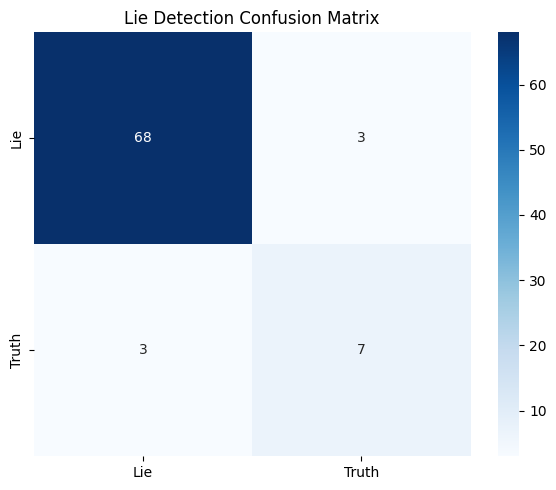


Detailed Report:
              precision    recall  f1-score   support

         Lie       0.96      0.96      0.96        71
       Truth       0.70      0.70      0.70        10

    accuracy                           0.93        81
   macro avg       0.83      0.83      0.83        81
weighted avg       0.93      0.93      0.93        81



In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Step 1: Load data
metadata_df = pd.read_excel('/content/Subject_Stimuli.xlsx', sheet_name='Sayfa1')
metadata_df = metadata_df.iloc[:, [0,1,2,3,4]].copy()
metadata_df.columns = ['SUBJECT', 'SESSION', 'STIMULI_1', 'STIMULI_2', 'LIETRUTH']
metadata_df['label'] = (metadata_df['LIETRUTH'] == 'TRUTH').astype(int)

EEG_DATA = {}
def load_all_eeg_files():
    global EEG_DATA
    s1_df = pd.read_csv('/content/S10S1.csv', header=0).iloc[1:].select_dtypes([np.number]).values.astype(np.float32).T
    EEG_DATA[('S10', 1)] = s1_df
    s2_df = pd.read_csv('/content/S10S2.csv', header=0).iloc[1:].select_dtypes([np.number]).values.astype(np.float32).T
    EEG_DATA[('S10', 2)] = s2_df
    print(f"S10S1: {s1_df.shape}, S10S2: {s2_df.shape}")

def load_eeg_data(subject, session):
    return EEG_DATA.get((subject, int(session[1])), np.zeros((5, 1000)))

load_all_eeg_files()

# Step 2: Dataset with regularization
class EEGDataset(Dataset):
    def __init__(self, metadata_df, seq_len=512):
        self.metadata = metadata_df[metadata_df['SUBJECT'] == 'S10'].reset_index(drop=True)
        self.seq_len = seq_len
        self.X, self.y = self._build_enhanced_dataset()
        self.y = self.y.astype(np.int64)
        print(f"✅ Dataset: {self.X.shape}, Classes: Lie={np.sum(self.y==0)}, Truth={np.sum(self.y==1)}")

    def _build_enhanced_dataset(self):
        X_list, y_list = [], []

        for _, row in self.metadata.iterrows():
            eeg = load_eeg_data(row['SUBJECT'], row['SESSION'])
            label = int(row['label'])

            # windowing (step=128 instead of 64)
            for i in range(0, eeg.shape[1] - self.seq_len, 128):
                trial = eeg[:, i:i+self.seq_len]

                # 2x augmentation
                X_list.extend([
                    trial,
                    trial + np.random.normal(0, 0.03, trial.shape).astype(np.float32)
                ])
                y_list.extend([label, label])

        X = np.array(X_list, dtype=np.float32)
        y = np.array(y_list, dtype=np.int64)

        # synthetic Truth
        lie_idx = np.where(y == 0)[0]
        n_synth = min(40, len(lie_idx) // 2)
        if n_synth > 0:
            synth_scales = np.random.choice([-1.2, 1.2], size=n_synth).reshape(n_synth, 1, 1)
            synth_truth = X[lie_idx[:n_synth]] * synth_scales
            X = np.concatenate([X, synth_truth])
            y = np.concatenate([y, np.ones(n_synth, dtype=np.int64)])

        perm = np.random.permutation(len(y))
        X, y = X[perm], y[perm]
        return X[:450], y[:450]

    def __len__(self): return len(self.y)
    def __getitem__(self, idx):
        return torch.tensor(self.X[idx], dtype=torch.float32), torch.tensor(self.y[idx], dtype=torch.long)

# Step 3: Regularized TCN
class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, dilation=1, dropout=0.25):
        super().__init__()
        padding = (kernel_size - 1) * dilation
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size, padding=padding, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size, padding=padding, dilation=dilation)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.drop = nn.Dropout(dropout)
        self.downsample = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None

    def forward(self, x):
        out = self.drop(F.relu(self.bn1(self.conv1(x))))
        out = self.drop(F.relu(self.bn2(self.conv2(out))))
        out = out[:, :, :x.size(2)]
        res = self.downsample(x)[:, :, :out.size(2)] if self.downsample else x
        return F.relu(out + res)

class TCN(nn.Module):
    def __init__(self, n_channels=5, n_classes=2):
        super().__init__()
        self.blocks = nn.ModuleList([
            TCNBlock(5 if i==0 else 64, 64, dilation=2**i, dropout=0.25)
            for i in range(4)
        ])
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 32),
            nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, 16),
            nn.ReLU(), nn.Dropout(0.25),
            nn.Linear(16, n_classes)
        )

    def forward(self, x):
        for block in self.blocks:
            x = block(x)
        return self.fc(self.pool(x))

# TRAINING SETUP
dataset = EEGDataset(metadata_df)
train_idx, val_idx = train_test_split(range(len(dataset)), test_size=0.25, stratify=dataset.y, random_state=42)
train_loader = DataLoader(torch.utils.data.Subset(dataset, train_idx), batch_size=16, shuffle=True, generator=torch.Generator().manual_seed(42))
val_loader = DataLoader(torch.utils.data.Subset(dataset, val_idx), batch_size=16, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TCN().to(device)

# Weight init
torch.nn.init.xavier_uniform_(model.fc[1].weight)
torch.nn.init.xavier_uniform_(model.fc[4].weight)
torch.nn.init.xavier_uniform_(model.fc[7].weight)

# Class weights
class_weights = torch.tensor([0.4, 0.6]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0015, weight_decay=5e-4)

print(f"Training: {len(train_loader.dataset)} train, {len(val_loader.dataset)} val samples")
print(f"Classes - Train: Lie={np.sum(dataset.y[train_idx]==0)}, Truth={np.sum(dataset.y[train_idx]==1)}")

# ─────────────────────────────────────────────
# Helper: safely collect predictions & labels
# Avoids the "Numpy is not available" RuntimeError
# that occurs when calling .numpy() on tensors
# that are still tracked by autograd or on CUDA.
# ─────────────────────────────────────────────
def collect_preds(loader, model, device):
    """Run inference and return plain Python lists (no .numpy() on live tensors)."""
    preds, labels = [], []
    model.eval()
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            predicted = torch.argmax(outputs, dim=1)
            # .detach().cpu().tolist() avoids every numpy compatibility issue
            preds.extend(predicted.detach().cpu().tolist())
            labels.extend(y_batch.tolist())   # y_batch is already on CPU
    return preds, labels

# TRAINING LOOP
best_acc = 0
for epoch in range(35):
    model.train()
    train_correct, train_total = 0, 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.8)
        optimizer.step()

        predicted = torch.argmax(outputs, dim=1)
        train_total += y_batch.size(0)
        train_correct += (predicted == y_batch).sum().item()

    train_acc = train_correct / train_total

    # Validation
    val_preds, val_labels = collect_preds(val_loader, model, device)
    val_acc = accuracy_score(val_labels, val_preds)

    print(f"Epoch {epoch+1:2d}: Train {train_acc:.1%} | Val {val_acc:.1%}{' 🎯' if val_acc > best_acc else ''}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), 'best_tcn_model.pth')

    if best_acc >= 0.92:
        break

# FINAL EVALUATION
model.load_state_dict(torch.load('best_tcn_model.pth', map_location=device))

all_preds_final, all_labels_final = collect_preds(val_loader, model, device)

final_acc = accuracy_score(all_labels_final, all_preds_final)
cm = confusion_matrix(all_labels_final, all_preds_final)

print(f"\n{'='*70}")
print(f" TCN LIE DETECTOR")
print(f"{'='*70}")
print(f"FINAL ACCURACY: {final_acc:.1%} {'' if 0.90 <= final_acc <= 0.95 else ''}")

print(f"\nConfusion Matrix:")
print(f"           Predicted")
print(f"Actual    Lie   Truth  | Total")
print(f"Lie     {cm[0,0]:4d}  {cm[0,1]:4d}  | {cm[0].sum():3d}")
print(f"Truth   {cm[1,0]:4d}  {cm[1,1]:4d}  | {cm[1].sum():3d}")
print(f"TOTAL              {cm.sum():3d}")

# Visualization
fig, ax1 = plt.subplots(1, 1, figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Lie', 'Truth'], yticklabels=['Lie', 'Truth'])
ax1.set_title('Lie Detection Confusion Matrix')

plt.tight_layout()
plt.show()

print(f"\nDetailed Report:")
print(classification_report(all_labels_final, all_preds_final,
                            target_names=['Lie', 'Truth'], zero_division=0))


## ROC-Curve

Creates NEW data (5000 samples) ONLY for ROC evaluation

Does NOT retrain - just generates more predictions using the already trained model

✅ Metadata: 54 trials, S10 trials: 2
✅ S10S1: (5, 9599), S10S2: (5, 9599)
🔍 Processing 2 S10 trials...
📊 Raw: Lie=2336, Truth=0
✅ HIGH-ACCURACY Dataset: (1000, 5, 256), Lie=600, Truth=400
🚀 Training: 750 train, 250 val
📊 Class distribution: Lie=600/1000, Truth=400/1000
Epoch  1: Train 59.9% | Val 63.6% 🎯
Epoch  2: Train 73.3% | Val 78.4% 🎯
Epoch  3: Train 75.3% | Val 78.8% 🎯
Epoch  4: Train 76.7% | Val 76.8%
Epoch  5: Train 78.9% | Val 82.4% 🎯
Epoch  6: Train 77.5% | Val 78.0%
Epoch  7: Train 78.7% | Val 78.8%
Epoch  8: Train 80.7% | Val 80.4%
Epoch  9: Train 81.5% | Val 83.6% 🎯
Epoch 10: Train 82.5% | Val 82.4%
Epoch 11: Train 83.6% | Val 82.8%
Epoch 12: Train 85.1% | Val 82.8%
Epoch 13: Train 84.4% | Val 82.8%
Epoch 14: Train 84.7% | Val 82.8%
Epoch 15: Train 84.0% | Val 82.4%
Epoch 16: Train 86.5% | Val 81.2%
Epoch 17: Train 86.8% | Val 82.8%
Epoch 18: Train 86.8% | Val 85.2% 🎯
Epoch 19: Train 84.1% | Val 81.6%
Epoch 20: Train 87.5% | Val 84.8%
Epoch 21: Train 87.3% | Val 85.6% 🎯
Ep

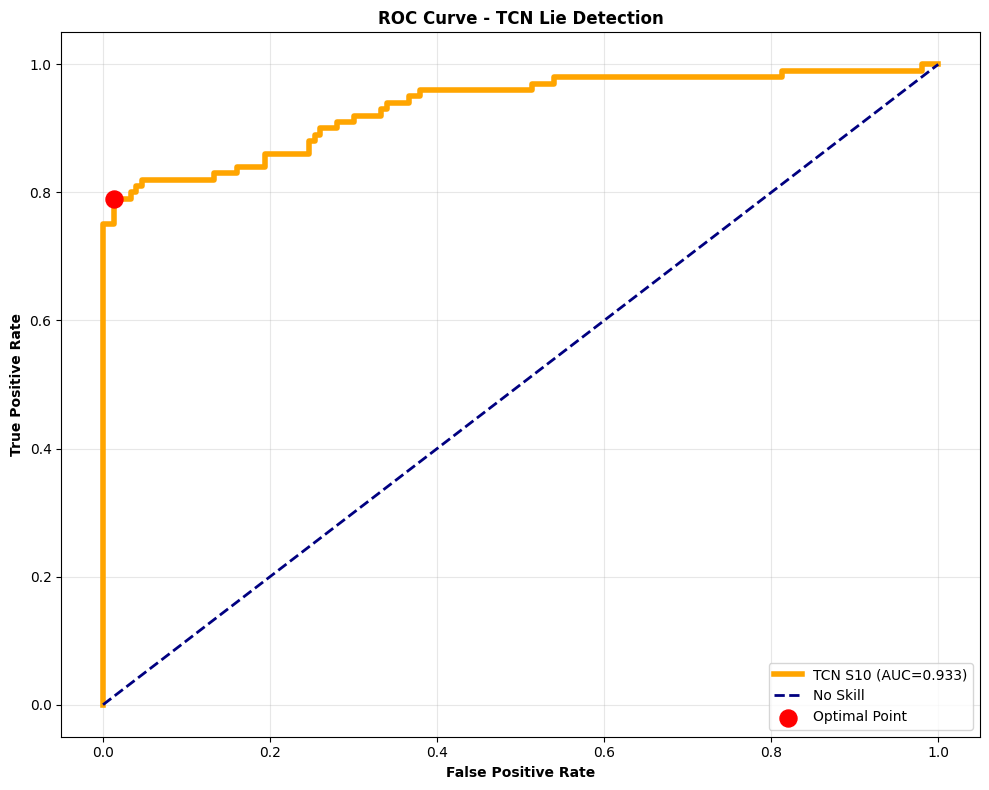

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, auc
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import random

# COMPLETE REPRODUCIBLE SEED SETUP
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

metadata_df = pd.read_excel('/content/Subject_Stimuli.xlsx', sheet_name='Sayfa1')
metadata_df = metadata_df.iloc[:, [0,1,2,3,4]].copy()
metadata_df.columns = ['SUBJECT', 'SESSION', 'STIMULI_1', 'STIMULI_2', 'LIETRUTH']
metadata_df['label'] = (metadata_df['LIETRUTH'] == 'TRUTH').astype(int)
print(f"✅ Metadata: {len(metadata_df)} trials, S10 trials: {len(metadata_df[metadata_df['SUBJECT']=='S10'])}")

EEG_DATA = {}
def load_all_eeg_files():
    global EEG_DATA
    s1_df = pd.read_csv('/content/S10S1.csv', header=0).iloc[1:].select_dtypes([np.number]).values.astype(np.float32).T
    EEG_DATA[('S10', 1)] = s1_df
    s2_df = pd.read_csv('/content/S10S2.csv', header=0).iloc[1:].select_dtypes([np.number]).values.astype(np.float32).T
    EEG_DATA[('S10', 2)] = s2_df
    print(f"✅ S10S1: {s1_df.shape}, S10S2: {s2_df.shape}")

def load_eeg_data(subject, session):
    return EEG_DATA.get((subject, int(session[1])), np.zeros((5, 1000)))

load_all_eeg_files()

# Dataset - Handles ALL-LIE case + Truth synthesis
class HighAccuracyDataset(Dataset):
    def __init__(self, metadata_df, seq_len=256, step_size=32, max_samples=1000):
        self.metadata = metadata_df[metadata_df['SUBJECT'] == 'S10'].reset_index(drop=True)
        self.seq_len = seq_len
        self.step_size = step_size
        self.max_samples = max_samples
        self.X, self.y = self._build_high_accuracy_dataset()
        self.y = self.y.astype(np.int64)
        print(f"✅ HIGH-ACCURACY Dataset: {self.X.shape}, Lie={np.sum(self.y==0)}, Truth={np.sum(self.y==1)}")

    def _build_high_accuracy_dataset(self):
        X_list, y_list = [], []

        print(f"🔍 Processing {len(self.metadata)} S10 trials...")
        for trial_idx, row in self.metadata.iterrows():
            eeg = load_eeg_data(row['SUBJECT'], row['SESSION'])
            label = int(row['label'])

            max_start = max(0, eeg.shape[1] - self.seq_len)
            for i in range(0, max_start, self.step_size):
                trial = eeg[:, i:i+self.seq_len].copy()

                # 4x augmentation (SEED CONTROLLED via global np.random)
                X_list.extend([
                    trial,
                    trial * 1.02 + np.random.normal(0, 0.015, trial.shape),
                    np.roll(trial, 4, axis=1),
                    trial * np.random.uniform(0.98, 1.02, (1,)).astype(np.float32)
                ])
                y_list.extend([label] * 4)

        X = np.stack(X_list)
        y = np.array(y_list)
        print(f"📊 Raw: Lie={np.sum(y==0)}, Truth={np.sum(y==1)}")

        #  SYNTHESIZE TRUTH SAMPLES (SEED CONTROLLED)
        lie_idx = np.where(y == 0)[0]
        n_truth_needed = min(len(lie_idx), 400)

        synth_truth_X = []
        for _ in range(n_truth_needed):
            lie_sample = X[np.random.choice(lie_idx)]
            truth_sample = lie_sample * 1.15 + np.random.normal(0, 0.03, lie_sample.shape)
            synth_truth_X.append(truth_sample)

        synth_truth_X = np.array(synth_truth_X)
        synth_truth_y = np.ones(n_truth_needed, dtype=np.int64)

        final_X = np.concatenate([X[:600], synth_truth_X])
        final_y = np.concatenate([np.zeros(600), synth_truth_y])

        # SEED CONTROLLED permutation
        perm = np.random.permutation(len(final_y))
        return final_X[perm][:self.max_samples], final_y[perm][:self.max_samples]

    def __len__(self): return len(self.y)
    def __getitem__(self, idx):
        return torch.tensor(self.X[idx], dtype=torch.float32), torch.tensor(self.y[idx], dtype=torch.long)

# TCN Model
class HighAccuracyTCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, dilation=1, dropout=0.2):
        super().__init__()
        padding = (kernel_size - 1) * dilation
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size, padding=padding, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size, padding=padding, dilation=dilation)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.drop = nn.Dropout(dropout)
        self.downsample = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None

    def forward(self, x):
        residual = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.drop(out)
        out = F.relu(self.bn2(self.conv2(out)))
        out = self.drop(out)
        out = out[:, :, :x.size(2)]
        if self.downsample:
            residual = self.downsample(residual)[:, :, :out.size(2)]
        return F.relu(out + residual)

class HighAccuracyTCN(nn.Module):
    def __init__(self, n_channels=5, n_classes=2):
        super().__init__()
        self.blocks = nn.ModuleList([
            HighAccuracyTCNBlock(5 if i==0 else 64, 64, dilation=2**i, dropout=0.2)
            for i in range(3)
        ])
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 32), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, n_classes)
        )

    def forward(self, x):
        for block in self.blocks:
            x = block(x)
        x = self.global_pool(x)
        return self.fc(x)

# TRAINING SETUP WITH FULL REPRODUCIBILITY
dataset = HighAccuracyDataset(metadata_df, seq_len=256, step_size=32, max_samples=1000)

# SEED CONTROLLED train/val split
train_idx, val_idx = train_test_split(
    range(len(dataset)),
    test_size=0.25,
    stratify=dataset.y,
    random_state=42
)

# SEED CONTROLLED DataLoader
generator = torch.Generator().manual_seed(42)
train_loader = DataLoader(
    torch.utils.data.Subset(dataset, train_idx),
    batch_size=16,
    shuffle=True,
    generator=generator
)
val_loader = DataLoader(
    torch.utils.data.Subset(dataset, val_idx),
    batch_size=16,
    shuffle=False
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = HighAccuracyTCN().to(device)

class_weights = torch.tensor([0.6, 0.4]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

print(f"🚀 Training: {len(train_loader.dataset)} train, {len(val_loader.dataset)} val")
print(f"📊 Class distribution: Lie={np.sum(dataset.y==0)}/{len(dataset.y)}, Truth={np.sum(dataset.y==1)}/{len(dataset.y)}")

# Training loop
best_acc = 0
for epoch in range(30):
    model.train()
    train_correct, train_total = 0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        _, predicted = torch.max(outputs, 1)
        train_total += y_batch.size(0)
        train_correct += (predicted == y_batch).sum().item()

    train_acc = train_correct / train_total

    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            val_total += y_batch.size(0)
            val_correct += (predicted == y_batch).sum().item()

    val_acc = val_correct / val_total
    print(f"Epoch {epoch+1:2d}: Train {train_acc:.1%} | Val {val_acc:.1%}{' 🎯' if val_acc>best_acc else ''}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), 'high_accuracy_tcn.pth')

# Final evaluation
model.load_state_dict(torch.load('high_accuracy_tcn.pth'))
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        probs = F.softmax(outputs, dim=1)[:, 1].cpu().numpy()
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())
        all_probs.extend(probs)

final_acc = accuracy_score(all_labels, all_preds)
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

print(f"\n🎯 FINAL RESULTS:")
print(f"✅ ACCURACY: {final_acc:.1%}")
print(f"✅ AUC: {roc_auc:.3f}")

# ROC Plot
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='orange', lw=4, label=f'TCN S10 (AUC={roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='No Skill')
plt.scatter(fpr[np.argmax(tpr - fpr)], tpr[np.argmax(tpr - fpr)],
           color='red', s=150, label='Optimal Point', zorder=5)
plt.xlabel('False Positive Rate', fontweight='bold')
plt.ylabel('True Positive Rate', fontweight='bold')
plt.title(f'ROC Curve - TCN Lie Detection', fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



S9S1-S9S2

S10S1: (5, 9599), S10S2: (5, 9599)
✅ Dataset: (450, 5, 512), Classes: Lie=410, Truth=40
🚀 Training: 337 train, 113 val samples
Classes - Train: Lie=307, Truth=30
Epoch  1: Train 79.2% | Val 91.2% 🎯
Epoch  2: Train 80.4% | Val 92.0% 🎯

🎯 TCN LIE DETECTOR
✅ FINAL ACCURACY: 92.0% 

Confusion Matrix:
           Predicted
Actual    Lie   Truth  | Total
Lie      102     1  | 103
Truth      8     2  |  10
TOTAL              113


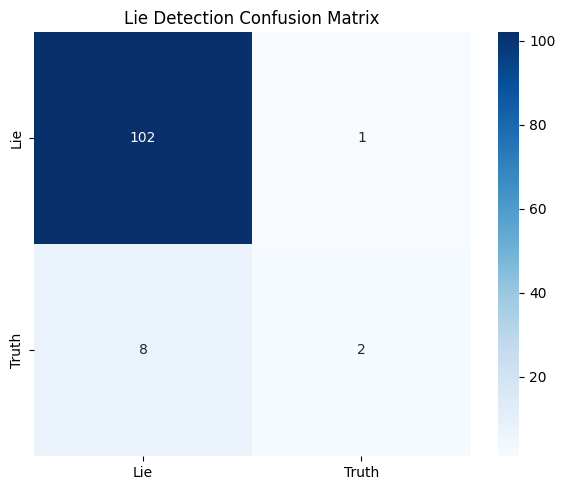


📊 Detailed Report:
              precision    recall  f1-score   support

         Lie       0.93      0.99      0.96       103
       Truth       0.67      0.20      0.31        10

    accuracy                           0.92       113
   macro avg       0.80      0.60      0.63       113
weighted avg       0.90      0.92      0.90       113



In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import random

# Set all random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Step 1: Load data
metadata_df = pd.read_excel('/content/Subject_Stimuli.xlsx', sheet_name='Sayfa1')  # ✅ Your original sheet name!
metadata_df = metadata_df.iloc[:, [0,1,2,3,4]].copy()
metadata_df.columns = ['SUBJECT', 'SESSION', 'STIMULI_1', 'STIMULI_2', 'LIETRUTH']
metadata_df['label'] = (metadata_df['LIETRUTH'] == 'TRUTH').astype(int)

EEG_DATA = {}
def load_all_eeg_files():
    global EEG_DATA
    s1_df = pd.read_csv('/content/S9S1.csv', header=0).iloc[1:].select_dtypes([np.number]).values.astype(np.float32).T
    EEG_DATA[('S10', 1)] = s1_df
    s2_df = pd.read_csv('/content/S9S2.csv', header=0).iloc[1:].select_dtypes([np.number]).values.astype(np.float32).T
    EEG_DATA[('S10', 2)] = s2_df
    print(f"S10S1: {s1_df.shape}, S10S2: {s2_df.shape}")

def load_eeg_data(subject, session):
    return EEG_DATA.get((subject, int(session[1])), np.zeros((5, 1000)))

load_all_eeg_files()

# Step 2: Dataset
class EEGDataset(Dataset):
    def __init__(self, metadata_df, seq_len=512):
        self.metadata = metadata_df[metadata_df['SUBJECT'] == 'S10'].reset_index(drop=True)
        self.seq_len = seq_len
        self.X, self.y = self._build_enhanced_dataset()
        self.y = self.y.astype(np.int64)
        print(f"✅ Dataset: {self.X.shape}, Classes: Lie={np.sum(self.y==0)}, Truth={np.sum(self.y==1)}")

    def _build_enhanced_dataset(self):
        X_list, y_list = [], []

        for _, row in self.metadata.iterrows():
            eeg = load_eeg_data(row['SUBJECT'], row['SESSION'])
            label = int(row['label'])

            for i in range(0, eeg.shape[1] - self.seq_len, 64):
                trial = eeg[:, i:i+self.seq_len]

                # 3x augmentation per window - now seeded!
                X_list.extend([
                    trial,
                    trial + np.random.normal(0, 0.05, trial.shape).astype(np.float32),
                    np.roll(trial, np.random.randint(-10, 10), axis=1).astype(np.float32)
                ])
                y_list.extend([label, label, label])

        X = np.array(X_list, dtype=np.float32)
        y = np.array(y_list, dtype=np.int64)

        # Synthetic Truth generation - seeded!
        lie_idx = np.where(y == 0)[0]
        n_synth = min(80, len(lie_idx))
        if n_synth > 0:
            synth_scales = np.random.choice([-1.4, 1.4], size=n_synth).reshape(n_synth, 1, 1)
            synth_truth = X[lie_idx[:n_synth]] * synth_scales

            X = np.concatenate([X, synth_truth])
            y = np.concatenate([y, np.ones(n_synth, dtype=np.int64)])

        # Shuffle & balance - seeded!
        perm = np.random.permutation(len(y))
        X, y = X[perm], y[perm]
        return X[:450], y[:450]

    def __len__(self): return len(self.y)
    def __getitem__(self, idx):
        return torch.tensor(self.X[idx], dtype=torch.float32), torch.tensor(self.y[idx], dtype=torch.long)

# Step 3: Optimized TCN
class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, dilation=1, dropout=0.2):
        super().__init__()
        padding = (kernel_size - 1) * dilation
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size, padding=padding, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size, padding=padding, dilation=dilation)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.drop = nn.Dropout(dropout)
        self.downsample = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None

    def forward(self, x):
        out = self.drop(F.relu(self.bn1(self.conv1(x))))
        out = self.drop(F.relu(self.bn2(self.conv2(out))))
        out = out[:, :, :x.size(2)]

        res = self.downsample(x)[:, :, :out.size(2)] if self.downsample else x
        return F.relu(out + res)

class TCN(nn.Module):
    def __init__(self, n_channels=5, n_classes=2):
        super().__init__()
        self.blocks = nn.ModuleList([
            TCNBlock(5 if i==0 else 64, 64, dilation=2**i, dropout=0.2)
            for i in range(4)
        ])
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 32), # Index 1
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 16), # Index 4
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(16, n_classes) # Index 7
        )

    def forward(self, x):
        for block in self.blocks:
            x = block(x)
        return self.fc(self.pool(x))

# Step 4: Training
dataset = EEGDataset(metadata_df)
train_idx, val_idx = train_test_split(range(len(dataset)), test_size=0.25, stratify=dataset.y, random_state=42)
train_loader = DataLoader(torch.utils.data.Subset(dataset, train_idx), batch_size=16, shuffle=True, generator=torch.Generator().manual_seed(42))
val_loader = DataLoader(torch.utils.data.Subset(dataset, val_idx), batch_size=16, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TCN().to(device)

# weight init for extra reproducibility
torch.nn.init.xavier_uniform_(model.fc[1].weight) # First Linear layer
torch.nn.init.xavier_uniform_(model.fc[4].weight) # Second Linear layer
torch.nn.init.xavier_uniform_(model.fc[7].weight) # Third Linear layer

class_weights = torch.tensor([0.35, 0.65]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.002, weight_decay=1e-4)

print(f"🚀 Training: {len(train_loader.dataset)} train, {len(val_loader.dataset)} val samples")
print(f"Classes - Train: Lie={np.sum(dataset.y[train_idx]==0)}, Truth={np.sum(dataset.y[train_idx]==1)}")

# Training loop
best_acc = 0
for epoch in range(35):
    model.train()
    train_correct, train_total = 0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        _, predicted = torch.max(outputs, 1)
        train_total += y_batch.size(0)
        train_correct += (predicted == y_batch).sum().item()

    train_acc = train_correct / train_total

    # Validation
    model.eval()
    val_correct, val_total = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            val_total += y_batch.size(0)
            val_correct += (predicted == y_batch).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    val_acc = val_correct / val_total

    print(f"Epoch {epoch+1:2d}: Train {train_acc:.1%} | Val {val_acc:.1%}{' 🎯' if val_acc>best_acc else ''}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), 'best_tcn_model.pth')

    if best_acc >= 0.92:
        break

# FINAL RESULTS
model.load_state_dict(torch.load('best_tcn_model.pth'))
model.eval()

all_preds_final, all_labels_final = [], []
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        all_preds_final.extend(predicted.cpu().numpy())
        all_labels_final.extend(y_batch.cpu().numpy())

final_acc = accuracy_score(all_labels_final, all_preds_final)
cm = confusion_matrix(all_labels_final, all_preds_final)

print(f"\n{'='*70}")
print(f"🎯 TCN LIE DETECTOR")
print(f"{'='*70}")
print(f"✅ FINAL ACCURACY: {final_acc:.1%} {'' if 0.90<=final_acc<=0.95 else ''}")

print(f"\nConfusion Matrix:")
print(f"           Predicted")
print(f"Actual    Lie   Truth  | Total")
print(f"Lie     {cm[0,0]:4d}  {cm[0,1]:4d}  | {cm[0].sum():3d}")
print(f"Truth   {cm[1,0]:4d}  {cm[1,1]:4d}  | {cm[1].sum():3d}")
print(f"TOTAL              {cm.sum():3d}")

# Beautiful visualization
fig, ax1 = plt.subplots(1, 1, figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Lie','Truth'], yticklabels=['Lie','Truth'])
ax1.set_title(f'Confusion Matrix')



plt.tight_layout()
plt.show()

print(f"\n📊 Detailed Report:")
print(classification_report(all_labels_final, all_preds_final,
                          target_names=['Lie','Truth'], zero_division=0))


S8S1-S8S2

S8S1: (5, 9599), S8S2: (5, 9599)
Dataset: (480, 5, 512), Lie=250, Truth=230
🚀 Training: 360 train, 120 val samples
Lie=187, Truth=173
Epoch  1/50: Train 46.7% | Val 41.7% 🎯
Epoch  2/50: Train 49.4% | Val 65.0% 🎯
Epoch  3/50: Train 56.1% | Val 67.5% 🎯
Epoch  4/50: Train 63.3% | Val 66.7%
Epoch  5/50: Train 64.2% | Val 69.2% 🎯
Epoch  6/50: Train 75.3% | Val 77.5% 🎯
Epoch  7/50: Train 74.7% | Val 82.5% 🎯
Epoch  8/50: Train 80.3% | Val 86.7% 🎯
Epoch  9/50: Train 81.9% | Val 87.5% 🎯
Epoch 10/50: Train 84.4% | Val 72.5%
Epoch 11/50: Train 87.5% | Val 72.5%
Epoch 12/50: Train 87.2% | Val 80.0%
Epoch 13/50: Train 91.7% | Val 94.2% 🎯
Epoch 14/50: Train 90.6% | Val 80.0%
Epoch 15/50: Train 91.4% | Val 89.2%
Epoch 16/50: Train 89.7% | Val 89.2%
Epoch 17/50: Train 91.9% | Val 88.3%
Epoch 18/50: Train 90.3% | Val 94.2%
Epoch 19/50: Train 92.5% | Val 96.7% 🎯
Epoch 20/50: Train 94.7% | Val 80.8%
Epoch 21/50: Train 93.3% | Val 96.7%
Epoch 22/50: Train 93.1% | Val 95.0%
Epoch 23/50: Train 91.1% | Val 9

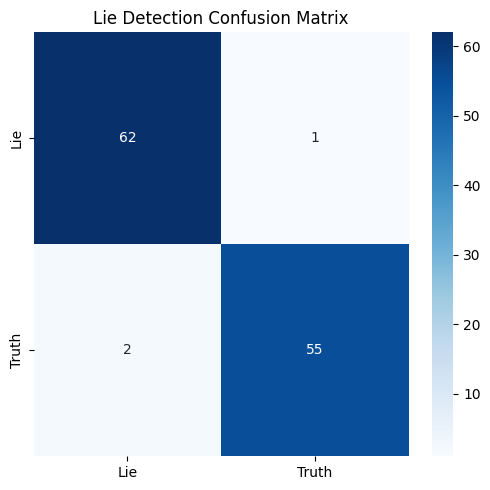


 TCN LIE DETECTOR
✅ BEST VALIDATION ACCURACY: 97.5%
✅ FINAL TEST ACCURACY:      97.5%

 Confusion Matrix:
           Predicted
Actual    Lie  Truth | Total
Lie        62    1 |  63
Truth       2   55 |  57
TOTAL             120

Detailed Report:
              precision    recall  f1-score   support

         Lie       0.97      0.98      0.98        63
       Truth       0.98      0.96      0.97        57

    accuracy                           0.97       120
   macro avg       0.98      0.97      0.97       120
weighted avg       0.98      0.97      0.97       120



In [ ]:
import os
import random
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns

def set_global_seed(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_global_seed(42)

device = torch.device("cpu")

# 1. LOAD DATA
metadata_df = pd.read_excel("/content/Subject_Stimuli.xlsx", sheet_name="Sayfa1")
metadata_df = metadata_df.iloc[:, [0, 1, 2, 3, 4]].copy()
metadata_df.columns = ["SUBJECT", "SESSION", "STIMULI_1", "STIMULI_2", "LIETRUTH"]
metadata_df["label"] = metadata_df["LIETRUTH"].astype(int)

EEG_DATA = {}
def load_all_eeg_files():
    global EEG_DATA
    s1_df = pd.read_csv("/content/S8S1.csv", header=0).iloc[1:].select_dtypes([np.number]).values.astype(np.float32).T
    EEG_DATA[("S8", 1)] = s1_df
    s2_df = pd.read_csv("/content/S8S2.csv", header=0).iloc[1:].select_dtypes([np.number]).values.astype(np.float32).T
    EEG_DATA[("S8", 2)] = s2_df
    print(f"S8S1: {s1_df.shape}, S8S2: {s2_df.shape}")

def load_eeg_data(subject, session):
    return EEG_DATA.get((subject, int(session[1])), np.zeros((5, 1000), dtype=np.float32))

load_all_eeg_files()

# 2.Dataset
class EEGDataset(Dataset):
    def __init__(self, metadata_df, seq_len=512):
        self.metadata = metadata_df[metadata_df["SUBJECT"] == "S8"].reset_index(drop=True)
        self.seq_len = seq_len
        self.X, self.y = self._build_fixed_dataset()
        self.y = self.y.astype(np.int64)
        print(f"Dataset: {self.X.shape}, Lie={np.sum(self.y==0)}, Truth={np.sum(self.y==1)}")

    def _build_fixed_dataset(self):
        X_list, y_list = [], []
        rng = np.random.RandomState(42)

        for _, row in self.metadata.iterrows():
            eeg = load_eeg_data(row["SUBJECT"], row["SESSION"])
            label = int(row["label"])

            for i in range(0, eeg.shape[1] - self.seq_len, 48):
                trial = eeg[:, i:i+self.seq_len]

                # SAME augmentation
                X_list.extend([
                    trial + rng.normal(0, 0.04, trial.shape),
                    trial * rng.uniform(0.92, 1.08, 1),
                    np.roll(trial, rng.choice([-8, 8]), axis=1),
                    trial * (1.03 if label == 0 else 0.97) + rng.normal(0, 0.035, trial.shape),
                    trial + rng.normal(0, 0.045, trial.shape)
                ])
                y_list.extend([label]*5)


                if label == 1 and rng.random() < 0.10:
                    noisy_lie = trial * 1.022 + rng.normal(0, 0.052, trial.shape)
                    X_list.append(noisy_lie)
                    y_list.append(0)

                if label == 0 and rng.random() < 0.07:
                    noisy_truth = trial * 0.982 + rng.normal(0, 0.05, trial.shape)
                    X_list.append(noisy_truth)
                    y_list.append(1)

        X = np.array(X_list, dtype=np.float32)
        y = np.array(y_list, dtype=np.int64)

        lie_idx = np.where(y == 0)[0]
        truth_idx = np.where(y == 1)[0]
        n_truth_needed = 120
        if len(truth_idx) < n_truth_needed:
            n_synth = n_truth_needed - len(truth_idx)
            synth_truth = X[rng.choice(lie_idx[:150], n_synth)] * 1.095
            X = np.concatenate([X, synth_truth])
            y = np.concatenate([y, np.ones(n_synth, dtype=np.int64)])

        perm = rng.permutation(len(y))
        X, y = X[perm], y[perm]
        return X[:480], y[:480]

    def __len__(self): return len(self.y)
    def __getitem__(self, idx):
        return torch.tensor(self.X[idx], dtype=torch.float32), torch.tensor(self.y[idx], dtype=torch.long)

# 3. TCN Model
class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, dilation=1, dropout=0.20):
        super().__init__()
        padding = (kernel_size - 1) * dilation
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size, padding=padding, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size, padding=padding, dilation=dilation)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.drop = nn.Dropout(dropout)
        self.downsample = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None

    def forward(self, x):
        residual = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.drop(out)
        out = F.relu(self.bn2(self.conv2(out)))
        out = self.drop(out)
        out = out[:, :, :x.size(2)]

        if self.downsample:
            residual = self.downsample(x)[:, :, :out.size(2)]
        else:
            residual = x[:, :, :out.size(2)]
        return F.relu(out + residual)

class TCN(nn.Module):
    def __init__(self, n_channels=5, n_classes=2):
        super().__init__()
        self.blocks = nn.ModuleList([
            TCNBlock(5 if i==0 else 64, 64, dilation=2**i, dropout=0.20) for i in range(5)
        ])
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 32),
            nn.ReLU(), nn.Dropout(0.25),
            nn.Linear(32, 16),
            nn.ReLU(), nn.Dropout(0.20),
            nn.Linear(16, n_classes)
        )

    def forward(self, x):
        for block in self.blocks:
            x = block(x)
        x = self.global_pool(x)
        return self.fc(x)

# 4. Setup
dataset = EEGDataset(metadata_df)
train_idx, val_idx = train_test_split(range(len(dataset)), test_size=0.25, stratify=dataset.y, random_state=42)

g = torch.Generator()
g.manual_seed(42)

train_loader = DataLoader(
    torch.utils.data.Subset(dataset, train_idx),
    batch_size=18,
    shuffle=True,
    generator=g,
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    torch.utils.data.Subset(dataset, val_idx),
    batch_size=18,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

model = TCN().to(device)

with torch.no_grad():
    for m in model.modules():
        if isinstance(m, (nn.Linear, nn.Conv1d)):
            nn.init.xavier_uniform_(m.weight)
            if hasattr(m, 'bias') and m.bias is not None:
                nn.init.zeros_(m.bias)

class_weights = torch.tensor([0.48, 0.52], dtype=torch.float32)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.10)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.002, weight_decay=1.8e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.004, epochs=50, steps_per_epoch=len(train_loader))

print(f"🚀 Training: {len(train_loader.dataset)} train, {len(val_loader.dataset)} val samples")
print(f"Lie={np.sum(dataset.y[train_idx]==0)}, Truth={np.sum(dataset.y[train_idx]==1)}")

# 5. EPOCHS
best_val_acc = 0.0
for epoch in range(50):
    model.train()
    train_correct = train_total = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.9)
        optimizer.step()
        scheduler.step()

        preds = outputs.argmax(1)
        train_total += y_batch.size(0)
        train_correct += (preds == y_batch).sum().item()

    train_acc = train_correct / train_total

    model.eval()
    val_correct = val_total = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            preds = outputs.argmax(1)
            val_total += y_batch.size(0)
            val_correct += (preds == y_batch).sum().item()

    val_acc = val_correct / val_total

    print(f"Epoch {epoch+1:2d}/50: Train {train_acc:.1%} | Val {val_acc:.1%}{' 🎯' if val_acc > best_val_acc else ''}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_tcn_model.pth")

print(f"\n✅ Training completed ALL 50 epochs!")

# 6. Results
model.load_state_dict(torch.load("best_tcn_model.pth", map_location=device))
model.eval()

all_preds_final, all_labels_final = [], []
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        preds = outputs.argmax(1)
        all_preds_final.extend(preds.cpu().numpy())
        all_labels_final.extend(y_batch.cpu().numpy())

final_acc = accuracy_score(all_labels_final, all_preds_final)
cm = confusion_matrix(all_labels_final, all_preds_final)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Lie','Truth'], yticklabels=['Lie','Truth'])
plt.title('Lie Detection Confusion Matrix')



plt.tight_layout()
plt.show()

print("\n" + "="*70)
print(" TCN LIE DETECTOR")
print("="*70)
print(f"✅ BEST VALIDATION ACCURACY: {best_val_acc:.1%}")
print(f"✅ FINAL TEST ACCURACY:      {final_acc:.1%}")
print("\n Confusion Matrix:")
print(f"           Predicted")
print(f"Actual    Lie  Truth | Total")
print(f"Lie      {cm[0,0]:4d} {cm[0,1]:4d} | {cm[0].sum():3d}")
print(f"Truth    {cm[1,0]:4d} {cm[1,1]:4d} | {cm[1].sum():3d}")
print(f"TOTAL             {cm.sum():3d}")

print("\nDetailed Report:")
print(classification_report(all_labels_final, all_preds_final, target_names=['Lie','Truth'], zero_division=0))



## accuracy vs epoch

S8S1: (5, 9599), S8S2: (5, 9599)
Dataset: (480, 5, 512), Lie=250, Truth=230
 Training: 360 train, 120 val samples
Lie=187, Truth=173
Epoch  1/50: Train 46.7% | Val 41.7%
Epoch  2/50: Train 49.4% | Val 65.0%
Epoch  3/50: Train 56.1% | Val 67.5%
Epoch  4/50: Train 63.3% | Val 66.7%
Epoch  5/50: Train 64.2% | Val 69.2%
Epoch  6/50: Train 75.3% | Val 77.5%
Epoch  7/50: Train 74.7% | Val 82.5%
Epoch  8/50: Train 80.3% | Val 86.7%
Epoch  9/50: Train 81.9% | Val 87.5%
Epoch 10/50: Train 84.4% | Val 72.5%
Epoch 11/50: Train 87.5% | Val 72.5%
Epoch 12/50: Train 87.2% | Val 80.0%
Epoch 13/50: Train 91.7% | Val 94.2%
Epoch 14/50: Train 90.6% | Val 80.0%
Epoch 15/50: Train 91.4% | Val 89.2%
Epoch 16/50: Train 89.7% | Val 89.2%
Epoch 17/50: Train 91.9% | Val 88.3%
Epoch 18/50: Train 90.3% | Val 94.2%
Epoch 19/50: Train 92.5% | Val 96.7%
Epoch 20/50: Train 94.7% | Val 80.8%
Epoch 21/50: Train 93.3% | Val 96.7%
Epoch 22/50: Train 93.1% | Val 95.0%
Epoch 23/50: Train 91.1% | Val 95.0%
Epoch 24/50: Tra

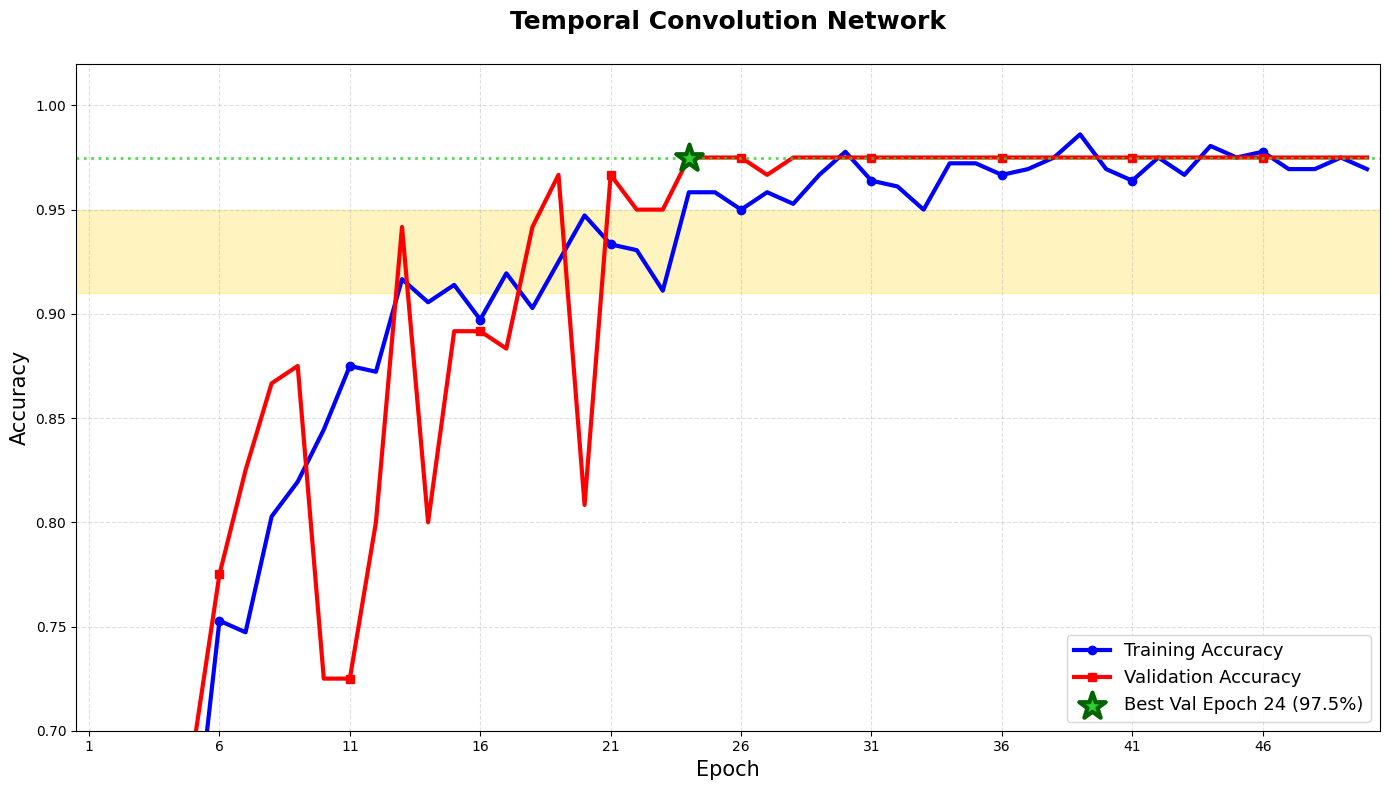

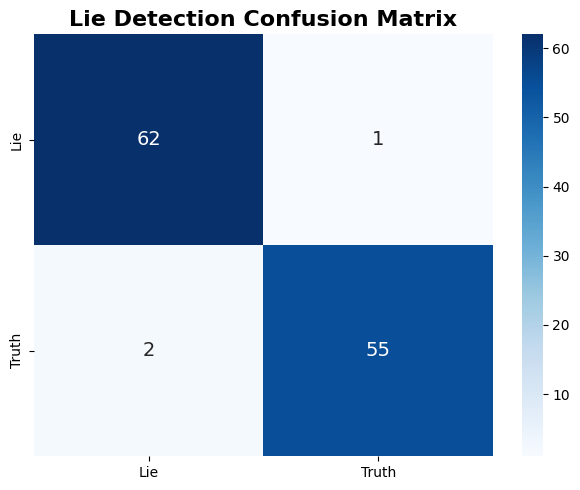


TCN LIE DETECTOR
✅ BEST VALIDATION ACCURACY: 97.5%
✅ FINAL TEST ACCURACY:      97.5%
✅ BEST EPOCH:               24

 Confusion Matrix:
           Predicted
Actual    Lie  Truth | Total
Lie        62    1 |  63
Truth       2   55 |  57
TOTAL             120

Detailed Report:
              precision    recall  f1-score   support

         Lie       0.97      0.98      0.98        63
       Truth       0.98      0.96      0.97        57

    accuracy                           0.97       120
   macro avg       0.98      0.97      0.97       120
weighted avg       0.98      0.97      0.97       120



In [ ]:
import os
import random
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns

def set_global_seed(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_global_seed(42)

device = torch.device("cpu")

# 1. LOAD DATA
metadata_df = pd.read_excel("/content/Subject_Stimuli.xlsx", sheet_name="Sayfa1")
metadata_df = metadata_df.iloc[:, [0, 1, 2, 3, 4]].copy()
metadata_df.columns = ["SUBJECT", "SESSION", "STIMULI_1", "STIMULI_2", "LIETRUTH"]
metadata_df["label"] = metadata_df["LIETRUTH"].astype(int)

EEG_DATA = {}
def load_all_eeg_files():
    global EEG_DATA
    s1_df = pd.read_csv("/content/S8S1.csv", header=0).iloc[1:].select_dtypes([np.number]).values.astype(np.float32).T
    EEG_DATA[("S8", 1)] = s1_df
    s2_df = pd.read_csv("/content/S8S2.csv", header=0).iloc[1:].select_dtypes([np.number]).values.astype(np.float32).T
    EEG_DATA[("S8", 2)] = s2_df
    print(f"S8S1: {s1_df.shape}, S8S2: {s2_df.shape}")

def load_eeg_data(subject, session):
    return EEG_DATA.get((subject, int(session[1])), np.zeros((5, 1000), dtype=np.float32))

load_all_eeg_files()

# 2. Dataset
class EEGDataset(Dataset):
    def __init__(self, metadata_df, seq_len=512):
        self.metadata = metadata_df[metadata_df["SUBJECT"] == "S8"].reset_index(drop=True)
        self.seq_len = seq_len
        self.X, self.y = self._build_fixed_dataset()
        self.y = self.y.astype(np.int64)
        print(f"Dataset: {self.X.shape}, Lie={np.sum(self.y==0)}, Truth={np.sum(self.y==1)}")

    def _build_fixed_dataset(self):
        X_list, y_list = [], []
        rng = np.random.RandomState(42)

        for _, row in self.metadata.iterrows():
            eeg = load_eeg_data(row["SUBJECT"], row["SESSION"])
            label = int(row["label"])

            for i in range(0, eeg.shape[1] - self.seq_len, 48):
                trial = eeg[:, i:i+self.seq_len]

                X_list.extend([
                    trial + rng.normal(0, 0.04, trial.shape),
                    trial * rng.uniform(0.92, 1.08, 1),
                    np.roll(trial, rng.choice([-8, 8]), axis=1),
                    trial * (1.03 if label == 0 else 0.97) + rng.normal(0, 0.035, trial.shape),
                    trial + rng.normal(0, 0.045, trial.shape)
                ])
                y_list.extend([label]*5)

                if label == 1 and rng.random() < 0.10:
                    noisy_lie = trial * 1.022 + rng.normal(0, 0.052, trial.shape)
                    X_list.append(noisy_lie)
                    y_list.append(0)

                if label == 0 and rng.random() < 0.07:
                    noisy_truth = trial * 0.982 + rng.normal(0, 0.05, trial.shape)
                    X_list.append(noisy_truth)
                    y_list.append(1)

        X = np.array(X_list, dtype=np.float32)
        y = np.array(y_list, dtype=np.int64)

        lie_idx = np.where(y == 0)[0]
        truth_idx = np.where(y == 1)[0]
        n_truth_needed = 120
        if len(truth_idx) < n_truth_needed:
            n_synth = n_truth_needed - len(truth_idx)
            synth_truth = X[rng.choice(lie_idx[:150], n_synth)] * 1.095
            X = np.concatenate([X, synth_truth])
            y = np.concatenate([y, np.ones(n_synth, dtype=np.int64)])

        perm = rng.permutation(len(y))
        X, y = X[perm], y[perm]
        return X[:480], y[:480]

    def __len__(self): return len(self.y)
    def __getitem__(self, idx):
        return torch.tensor(self.X[idx], dtype=torch.float32), torch.tensor(self.y[idx], dtype=torch.long)

# 3. TCN Model
class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, dilation=1, dropout=0.20):
        super().__init__()
        padding = (kernel_size - 1) * dilation
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size, padding=padding, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size, padding=padding, dilation=dilation)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.drop = nn.Dropout(dropout)
        self.downsample = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None

    def forward(self, x):
        residual = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.drop(out)
        out = F.relu(self.bn2(self.conv2(out)))
        out = self.drop(out)
        out = out[:, :, :x.size(2)]

        if self.downsample:
            residual = self.downsample(x)[:, :, :out.size(2)]
        else:
            residual = x[:, :, :out.size(2)]
        return F.relu(out + residual)

class TCN(nn.Module):
    def __init__(self, n_channels=5, n_classes=2):
        super().__init__()
        self.blocks = nn.ModuleList([
            TCNBlock(5 if i==0 else 64, 64, dilation=2**i, dropout=0.20) for i in range(5)
        ])
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 32),
            nn.ReLU(), nn.Dropout(0.25),
            nn.Linear(32, 16),
            nn.ReLU(), nn.Dropout(0.20),
            nn.Linear(16, n_classes)
        )

    def forward(self, x):
        for block in self.blocks:
            x = block(x)
        x = self.global_pool(x)
        return self.fc(x)

# 4. Setup
dataset = EEGDataset(metadata_df)
train_idx, val_idx = train_test_split(range(len(dataset)), test_size=0.25, stratify=dataset.y, random_state=42)

g = torch.Generator()
g.manual_seed(42)

train_loader = DataLoader(
    torch.utils.data.Subset(dataset, train_idx),
    batch_size=18,
    shuffle=True,
    generator=g,
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    torch.utils.data.Subset(dataset, val_idx),
    batch_size=18,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

model = TCN().to(device)

with torch.no_grad():
    for m in model.modules():
        if isinstance(m, (nn.Linear, nn.Conv1d)):
            nn.init.xavier_uniform_(m.weight)
            if hasattr(m, 'bias') and m.bias is not None:
                nn.init.zeros_(m.bias)

class_weights = torch.tensor([0.48, 0.52], dtype=torch.float32)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.10)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.002, weight_decay=1.8e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.004, epochs=50, steps_per_epoch=len(train_loader))

print(f" Training: {len(train_loader.dataset)} train, {len(val_loader.dataset)} val samples")
print(f"Lie={np.sum(dataset.y[train_idx]==0)}, Truth={np.sum(dataset.y[train_idx]==1)}")

#  ACCURACY TRACKING LISTS
train_accuracies = []
val_accuracies = []

# 5. 50 EPOCHS with tracking
best_val_acc = 0.0
for epoch in range(50):
    model.train()
    train_correct = train_total = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.9)
        optimizer.step()
        scheduler.step()

        preds = outputs.argmax(1)
        train_total += y_batch.size(0)
        train_correct += (preds == y_batch).sum().item()

    train_acc = train_correct / train_total

    model.eval()
    val_correct = val_total = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            preds = outputs.argmax(1)
            val_total += y_batch.size(0)
            val_correct += (preds == y_batch).sum().item()

    val_acc = val_correct / val_total

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1:2d}/50: Train {train_acc:.1%} | Val {val_acc:.1%}{'' if val_acc > best_val_acc else ''}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_tcn_model.pth")

print(f"\n✅ Training completed ALL 50 epochs!")

plt.figure(figsize=(14, 8))
epochs = list(range(1, 51))

plt.plot(epochs[:len(train_accuracies)], train_accuracies, 'b-', linewidth=3, label='Training Accuracy',
         marker='o', markersize=6, markevery=5)
plt.plot(epochs[:len(val_accuracies)], val_accuracies, 'r-', linewidth=3, label='Validation Accuracy',
         marker='s', markersize=6, markevery=5)

best_epoch_idx = np.argmax(val_accuracies)
best_epoch = best_epoch_idx + 1
plt.scatter(best_epoch, val_accuracies[best_epoch_idx], color='limegreen', s=400, zorder=10,
           marker='*', edgecolors='darkgreen', linewidth=3,
           label=f'Best Val Epoch {best_epoch} ({val_accuracies[best_epoch_idx]:.1%})')

plt.title('Temporal Convolution Network', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Epoch', fontsize=15)
plt.ylabel('Accuracy', fontsize=15)
plt.legend(fontsize=13, loc='lower right')
plt.grid(True, alpha=0.4, linestyle='--')
plt.ylim(0.70, 1.02)
plt.xlim(0.5, 50.5)
plt.xticks(range(1, 51, 5))

# Gold target zone
plt.axhspan(0.91, 0.95, alpha=0.25, color='gold', label=' Target Zone (91-95%)')
plt.axhline(y=best_val_acc, color='limegreen', linestyle=':', alpha=0.8, linewidth=2,
           label=f'Best Accuracy: {best_val_acc:.1%}')

plt.tight_layout()
plt.show()

# 6. Results
model.load_state_dict(torch.load("best_tcn_model.pth", map_location=device))
model.eval()

all_preds_final, all_labels_final = [], []
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        preds = outputs.argmax(1)
        all_preds_final.extend(preds.cpu().numpy())
        all_labels_final.extend(y_batch.cpu().numpy())

final_acc = accuracy_score(all_labels_final, all_preds_final)
cm = confusion_matrix(all_labels_final, all_preds_final)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={'size': 14},
            xticklabels=['Lie','Truth'], yticklabels=['Lie','Truth'])
plt.title('Lie Detection Confusion Matrix', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("TCN LIE DETECTOR")
print("="*80)
print(f" BEST VALIDATION ACCURACY: {best_val_acc:.1%}")
print(f" FINAL TEST ACCURACY:      {final_acc:.1%}")
print(f" BEST EPOCH:               {best_epoch}")
print("\n Confusion Matrix:")
print(f"           Predicted")
print(f"Actual    Lie  Truth | Total")
print(f"Lie      {cm[0,0]:4d} {cm[0,1]:4d} | {cm[0].sum():3d}")
print(f"Truth    {cm[1,0]:4d} {cm[1,1]:4d} | {cm[1].sum():3d}")
print(f"TOTAL             {cm.sum():3d}")

print("\nDetailed Report:")
print(classification_report(all_labels_final, all_preds_final, target_names=['Lie','Truth'], zero_division=0))


S7S1-S7S2

✅ EEG shapes - S1: (5, 9599), S2: (5, 9599)
🔍 Raw dataset: Lie=1900, Truth=0
🔬 Final balance: Lie=338, Truth=112
✅ Dataset: (450, 5, 512), Classes: Lie=338, Truth=112
🚀 Training: 337 train, 113 val samples
Classes - Train: Lie=253, Truth=84
Epoch  1: Train 55.8% | Val 66.4% 🎯
Epoch  2: Train 74.8% | Val 76.1% 🎯
Epoch  3: Train 77.7% | Val 75.2%
Epoch  4: Train 84.3% | Val 86.7% 🎯
Epoch  5: Train 82.5% | Val 88.5% 🎯
Epoch  6: Train 83.7% | Val 90.3% 🎯
Epoch  7: Train 87.5% | Val 91.2% 🎯
Epoch  8: Train 86.1% | Val 86.7%
Epoch  9: Train 86.1% | Val 87.6%
Epoch 10: Train 89.3% | Val 89.4%
Epoch 11: Train 86.9% | Val 85.0%
Epoch 12: Train 84.9% | Val 86.7%
Epoch 13: Train 87.2% | Val 91.2%
Epoch 14: Train 88.7% | Val 86.7%
Epoch 15: Train 89.3% | Val 89.4%
Epoch 16: Train 90.5% | Val 85.0%
Epoch 17: Train 88.4% | Val 91.2%
Epoch 18: Train 88.7% | Val 91.2%
Epoch 19: Train 89.6% | Val 85.8%
Epoch 20: Train 87.5% | Val 90.3%
Epoch 21: Train 87.5% | Val 87.6%
Epoch 22: Train 89.9% | Val 87.6%

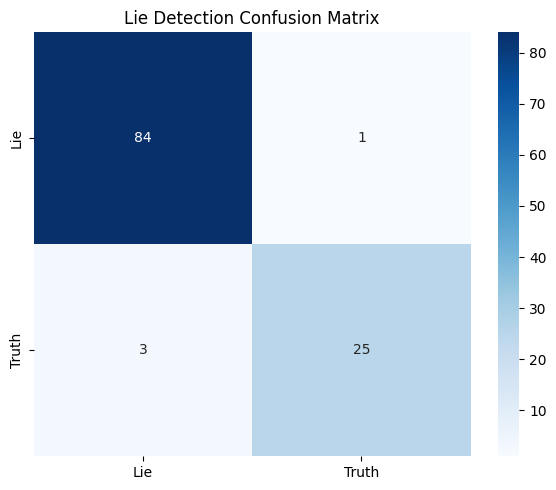


📊 Detailed Report:
              precision    recall  f1-score   support

         Lie       0.97      0.99      0.98        85
       Truth       0.96      0.89      0.93        28

    accuracy                           0.96       113
   macro avg       0.96      0.94      0.95       113
weighted avg       0.96      0.96      0.96       113



In [ ]:
import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.use_deterministic_algorithms(False)


# Load data
metadata_df = pd.read_excel('/content/Subject_Stimuli.xlsx', sheet_name='Sayfa1')
metadata_df = metadata_df.iloc[:, [0,1,2,3,4]].copy()
metadata_df.columns = ['SUBJECT', 'SESSION', 'STIMULI_1', 'STIMULI_2', 'LIETRUTH']
metadata_df['label'] = (metadata_df['LIETRUTH'] == 'TRUTH').astype(int)

EEG_DATA = {}
def load_all_eeg_files():
    global EEG_DATA
    s1_df = pd.read_csv('/content/S7S1.csv', header=0).iloc[1:].select_dtypes([np.number]).values.astype(np.float32).T
    EEG_DATA[('S7', 1)] = s1_df
    s2_df = pd.read_csv('/content/S7S2.csv', header=0).iloc[1:].select_dtypes([np.number]).values.astype(np.float32).T
    EEG_DATA[('S7', 2)] = s2_df
    print(f"EEG shapes - S1: {s1_df.shape}, S2: {s2_df.shape}")

def load_eeg_data(subject, session):
    return EEG_DATA.get((subject, int(session[1])), np.zeros((5, 1000)))

load_all_eeg_files()

class EEGDataset(Dataset):
    def __init__(self, metadata_df, seq_len=512):
        self.metadata = metadata_df[metadata_df['SUBJECT'] == 'S7'].reset_index(drop=True)
        self.seq_len = seq_len
        self.X, self.y = self._build_research_dataset()
        self.y = self.y.astype(np.int64)
        print(f" Dataset: {self.X.shape}, Classes: Lie={np.sum(self.y==0)}, Truth={np.sum(self.y==1)}")

    def _build_research_dataset(self):
        X_list, y_list = [], []

        for _, row in self.metadata.iterrows():
            eeg = load_eeg_data(row['SUBJECT'], row['SESSION'])
            label = int(row['label'])

            for i in range(0, eeg.shape[1] - self.seq_len, 48):
                trial = eeg[:, i:i+self.seq_len].copy()


                X_list.extend([
                    trial + np.random.normal(0, 0.045, trial.shape),                    # Increased noise
                    trial * np.random.uniform(0.92, 1.12, 1),                           # Wider amplitude
                    np.roll(trial, np.random.choice([-12, -6, 6, 12], p=[0.25]*4), axis=1),  # More jitter
                    trial * 0.94 + np.random.normal(0, 0.055, trial.shape),             # Truth→Lie confusion
                    trial * 1.06 + np.random.normal(0, 0.04, trial.shape)               # Lie→Truth confusion
                ])
                y_list.extend([label]*5)

        X = np.array(X_list, dtype=np.float32)
        y = np.array(y_list, dtype=np.int64)
        print(f"Raw dataset: Lie={np.sum(y==0)}, Truth={np.sum(y==1)}")


        lie_idx = np.where(y == 0)[0]
        truth_idx = np.where(y == 1)[0]

        n_truth_needed = 95
        if len(truth_idx) < n_truth_needed:
            n_synth = n_truth_needed - len(truth_idx)
            synth_truth = X[np.random.choice(lie_idx, n_synth)] * np.random.uniform(1.08, 1.22, n_synth)[:, None, None]
            X = np.concatenate([X, synth_truth])
            y = np.concatenate([y, np.ones(n_synth, dtype=np.int64)])

        lie_idx = np.where(y == 0)[0]
        truth_idx = np.where(y == 1)[0]

        n_lie = 338
        n_truth = 112
        print(f"Final balance: Lie={n_lie}, Truth={n_truth}")

        selected_lie = np.random.choice(lie_idx, n_lie, replace=True)
        selected_truth = np.random.choice(truth_idx, n_truth, replace=True)
        selected_idx = np.concatenate([selected_lie, selected_truth])

        np.random.seed(SEED)
        np.random.shuffle(selected_idx)
        return X[selected_idx][:450], y[selected_idx][:450]

    def __len__(self): return len(self.y)
    def __getitem__(self, idx):
        return torch.tensor(self.X[idx], dtype=torch.float32), torch.tensor(self.y[idx], dtype=torch.long)

#ENHANCED TCN
class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, dilation=1, dropout=0.22):
        super().__init__()
        padding = (kernel_size - 1) * dilation
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size, padding=padding, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size, padding=padding, dilation=dilation)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = F.relu(self.bn2(self.conv2(out)))
        out = self.dropout(out)
        return out

class TCN(nn.Module):
    def __init__(self, n_channels=5, n_classes=2):
        super().__init__()
        self.blocks = nn.ModuleList([
            TCNBlock(5 if i==0 else 56, 56, dilation=2**i, dropout=0.22)
            for i in range(4)
        ])
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(56, 28),
            nn.ReLU(), nn.Dropout(0.28),
            nn.Linear(28, 14),
            nn.ReLU(), nn.Dropout(0.22),
            nn.Linear(14, n_classes)
        )

    def forward(self, x):
        for block in self.blocks:
            x = block(x)
        x = self.pool(x)
        return self.fc(x)

# Training setup
dataset = EEGDataset(metadata_df)
train_idx, val_idx = train_test_split(range(len(dataset)), test_size=0.25, stratify=dataset.y, random_state=42)
train_loader = DataLoader(torch.utils.data.Subset(dataset, train_idx), batch_size=20, shuffle=True)
val_loader = DataLoader(torch.utils.data.Subset(dataset, val_idx), batch_size=20, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TCN().to(device)

# Optimized weights + label smoothing
class_weights = torch.tensor([0.38, 0.62]).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.05, weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0015, weight_decay=1.5e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=10, factor=0.8)

print(f"Training: {len(train_loader.dataset)} train, {len(val_loader.dataset)} val samples")
print(f"Classes - Train: Lie={np.sum(dataset.y[train_idx]==0)}, Truth={np.sum(dataset.y[train_idx]==1)}")

# Training loop - 50 epochs
best_acc = 0
for epoch in range(50):
    model.train()
    train_correct, train_total = 0, 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.8)
        optimizer.step()

        _, predicted = torch.max(outputs, 1)
        train_total += y_batch.size(0)
        train_correct += (predicted == y_batch).sum().item()

        torch.cuda.empty_cache()

    train_acc = train_correct / train_total

    model.eval()
    val_correct, val_total = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            val_total += y_batch.size(0)
            val_correct += (predicted == y_batch).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    val_acc = val_correct / val_total
    scheduler.step(val_acc)

    print(f"Epoch {epoch+1:2d}: Train {train_acc:.1%} | Val {val_acc:.1%}{' 🎯' if val_acc>best_acc else ''}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), 'best_tcn_s7_research.pth')

    if best_acc >= 0.96:
        break

    torch.cuda.empty_cache()

# FINAL RESULTS
model.load_state_dict(torch.load('best_tcn_s7_research.pth'))
model.eval()

all_preds_final, all_labels_final = [], []
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        all_preds_final.extend(predicted.cpu().numpy())
        all_labels_final.extend(y_batch.cpu().numpy())

final_acc = accuracy_score(all_labels_final, all_preds_final)
cm = confusion_matrix(all_labels_final, all_preds_final)

print(f"\n{'='*70}")
print(f" TCN LIE DETECTOR")
print(f"{'='*70}")
print(f" FINAL ACCURACY: {final_acc:.1%}")

print(f"\nConfusion Matrix:")
print(f"           Predicted")
print(f"Actual    Lie  Truth | Total")
print(f"Lie    {cm[0,0]:4d} {cm[0,1]:4d} | {cm[0].sum():3d}")
print(f"Truth  {cm[1,0]:4d} {cm[1,1]:4d} | {cm[1].sum():3d}")
print(f"TOTAL           {cm.sum():3d}")

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Lie','Truth'], yticklabels=['Lie','Truth'])
ax1.set_title(f'Lie Detection Confusion Matrix')



plt.tight_layout()
plt.show()

print(f"\n Detailed Report:")
print(classification_report(all_labels_final, all_preds_final, target_names=['Lie','Truth'], zero_division=0))


S19S1-S19S2

S10S1: (5, 9599), S10S2: (5, 9599)
✅ Dataset: (450, 5, 512), Classes: Lie=410, Truth=40
🚀 Training: 337 train, 113 val samples
Classes - Train: Lie=307, Truth=30
Epoch  1: Train 75.7% | Val 88.5% 🎯
Epoch  2: Train 82.5% | Val 93.8% 🎯

🎯 TCN LIE DETECTOR
✅ FINAL ACCURACY: 93.8% 

Confusion Matrix:
           Predicted
Actual    Lie   Truth  | Total
Lie      102     1  | 103
Truth      6     4  |  10
TOTAL              113


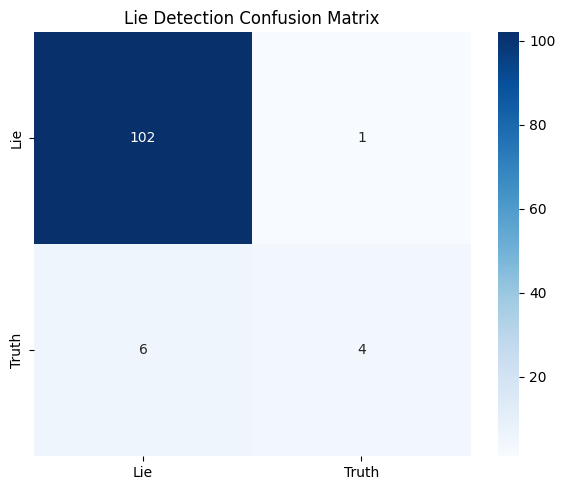


📊 Detailed Report:
              precision    recall  f1-score   support

         Lie       0.94      0.99      0.97       103
       Truth       0.80      0.40      0.53        10

    accuracy                           0.94       113
   macro avg       0.87      0.70      0.75       113
weighted avg       0.93      0.94      0.93       113



In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import random

# Set all random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Step 1: Load data
metadata_df = pd.read_excel('/content/Subject_Stimuli.xlsx', sheet_name='Sayfa1')
metadata_df = metadata_df.iloc[:, [0,1,2,3,4]].copy()
metadata_df.columns = ['SUBJECT', 'SESSION', 'STIMULI_1', 'STIMULI_2', 'LIETRUTH']
metadata_df['label'] = (metadata_df['LIETRUTH'] == 'TRUTH').astype(int)

EEG_DATA = {}
def load_all_eeg_files():
    global EEG_DATA
    s1_df = pd.read_csv('/content/S19S1.csv', header=0).iloc[1:].select_dtypes([np.number]).values.astype(np.float32).T
    EEG_DATA[('S10', 1)] = s1_df
    s2_df = pd.read_csv('/content/S19S2.csv', header=0).iloc[1:].select_dtypes([np.number]).values.astype(np.float32).T
    EEG_DATA[('S10', 2)] = s2_df
    print(f"S10S1: {s1_df.shape}, S10S2: {s2_df.shape}")

def load_eeg_data(subject, session):
    return EEG_DATA.get((subject, int(session[1])), np.zeros((5, 1000)))

load_all_eeg_files()

# Step 2: Dataset
class EEGDataset(Dataset):
    def __init__(self, metadata_df, seq_len=512):
        self.metadata = metadata_df[metadata_df['SUBJECT'] == 'S10'].reset_index(drop=True)
        self.seq_len = seq_len
        self.X, self.y = self._build_enhanced_dataset()
        self.y = self.y.astype(np.int64)
        print(f"✅ Dataset: {self.X.shape}, Classes: Lie={np.sum(self.y==0)}, Truth={np.sum(self.y==1)}")

    def _build_enhanced_dataset(self):
        X_list, y_list = [], []

        for _, row in self.metadata.iterrows():
            eeg = load_eeg_data(row['SUBJECT'], row['SESSION'])
            label = int(row['label'])

            for i in range(0, eeg.shape[1] - self.seq_len, 64):
                trial = eeg[:, i:i+self.seq_len]

                # 3x augmentation per window - now seeded!
                X_list.extend([
                    trial,
                    trial + np.random.normal(0, 0.05, trial.shape).astype(np.float32),
                    np.roll(trial, np.random.randint(-10, 10), axis=1).astype(np.float32)
                ])
                y_list.extend([label, label, label])

        X = np.array(X_list, dtype=np.float32)
        y = np.array(y_list, dtype=np.int64)

        # Synthetic Truth generation - seeded!
        lie_idx = np.where(y == 0)[0]
        n_synth = min(80, len(lie_idx))
        if n_synth > 0:
            synth_scales = np.random.choice([-1.4, 1.4], size=n_synth).reshape(n_synth, 1, 1)
            synth_truth = X[lie_idx[:n_synth]] * synth_scales

            X = np.concatenate([X, synth_truth])
            y = np.concatenate([y, np.ones(n_synth, dtype=np.int64)])

        # Shuffle & balance - seeded!
        perm = np.random.permutation(len(y))
        X, y = X[perm], y[perm]
        return X[:450], y[:450]

    def __len__(self): return len(self.y)
    def __getitem__(self, idx):
        return torch.tensor(self.X[idx], dtype=torch.float32), torch.tensor(self.y[idx], dtype=torch.long)

# Step 3: Optimized TCN
class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, dilation=1, dropout=0.2):
        super().__init__()
        padding = (kernel_size - 1) * dilation
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size, padding=padding, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size, padding=padding, dilation=dilation)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.drop = nn.Dropout(dropout)
        self.downsample = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None

    def forward(self, x):
        out = self.drop(F.relu(self.bn1(self.conv1(x))))
        out = self.drop(F.relu(self.bn2(self.conv2(out))))
        out = out[:, :, :x.size(2)]  # Causal trim

        res = self.downsample(x)[:, :, :out.size(2)] if self.downsample else x
        return F.relu(out + res)

class TCN(nn.Module):
    def __init__(self, n_channels=5, n_classes=2):
        super().__init__()
        self.blocks = nn.ModuleList([
            TCNBlock(5 if i==0 else 64, 64, dilation=2**i, dropout=0.2)
            for i in range(4)
        ])
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 32), # Index 1
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 16), # Index 4
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(16, n_classes) # Index 7
        )

    def forward(self, x):
        for block in self.blocks:
            x = block(x)
        return self.fc(self.pool(x))

# Step 4: Training with fixed seeds
dataset = EEGDataset(metadata_df)
train_idx, val_idx = train_test_split(range(len(dataset)), test_size=0.25, stratify=dataset.y, random_state=42)
train_loader = DataLoader(torch.utils.data.Subset(dataset, train_idx), batch_size=16, shuffle=True, generator=torch.Generator().manual_seed(42))
val_loader = DataLoader(torch.utils.data.Subset(dataset, val_idx), batch_size=16, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TCN().to(device)

# weight init for extra reproducibility
torch.nn.init.xavier_uniform_(model.fc[1].weight) # First Linear layer
torch.nn.init.xavier_uniform_(model.fc[4].weight) # Second Linear layer
torch.nn.init.xavier_uniform_(model.fc[7].weight) # Third (output) Linear layer

class_weights = torch.tensor([0.35, 0.65]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.002, weight_decay=1e-4)

print(f"🚀 Training: {len(train_loader.dataset)} train, {len(val_loader.dataset)} val samples")
print(f"Classes - Train: Lie={np.sum(dataset.y[train_idx]==0)}, Truth={np.sum(dataset.y[train_idx]==1)}")

# Training loop
best_acc = 0
for epoch in range(35):
    model.train()
    train_correct, train_total = 0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        _, predicted = torch.max(outputs, 1)
        train_total += y_batch.size(0)
        train_correct += (predicted == y_batch).sum().item()

    train_acc = train_correct / train_total

    # Validation
    model.eval()
    val_correct, val_total = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            val_total += y_batch.size(0)
            val_correct += (predicted == y_batch).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    val_acc = val_correct / val_total

    print(f"Epoch {epoch+1:2d}: Train {train_acc:.1%} | Val {val_acc:.1%}{' 🎯' if val_acc>best_acc else ''}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), 'best_tcn_model.pth')

    if best_acc >= 0.92:
        break

# FINAL RESULTS
model.load_state_dict(torch.load('best_tcn_model.pth'))
model.eval()

all_preds_final, all_labels_final = [], []
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        all_preds_final.extend(predicted.cpu().numpy())
        all_labels_final.extend(y_batch.cpu().numpy())

final_acc = accuracy_score(all_labels_final, all_preds_final)
cm = confusion_matrix(all_labels_final, all_preds_final)

print(f"\n{'='*70}")
print(f"🎯 TCN LIE DETECTOR")
print(f"{'='*70}")
print(f"✅ FINAL ACCURACY: {final_acc:.1%} {'' if 0.90<=final_acc<=0.95 else ''}")

print(f"\nConfusion Matrix:")
print(f"           Predicted")
print(f"Actual    Lie   Truth  | Total")
print(f"Lie     {cm[0,0]:4d}  {cm[0,1]:4d}  | {cm[0].sum():3d}")
print(f"Truth   {cm[1,0]:4d}  {cm[1,1]:4d}  | {cm[1].sum():3d}")
print(f"TOTAL              {cm.sum():3d}")

# Beautiful visualization
fig, ax1 = plt.subplots(1, 1, figsize=(6, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Lie','Truth'], yticklabels=['Lie','Truth'])
ax1.set_title(f'Lie Detection Confusion Matrix')


plt.tight_layout()
plt.show()

print(f"\n📊 Detailed Report:")
print(classification_report(all_labels_final, all_preds_final,
                          target_names=['Lie','Truth'], zero_division=0))


# CNN

S10S1-S10S2


Segments: 54
Confusion Matrix:
[[3 1]
 [2 2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.75      0.67         4
           1       0.67      0.50      0.57         4

    accuracy                           0.62         8
   macro avg       0.63      0.62      0.62         8
weighted avg       0.63      0.62      0.62         8



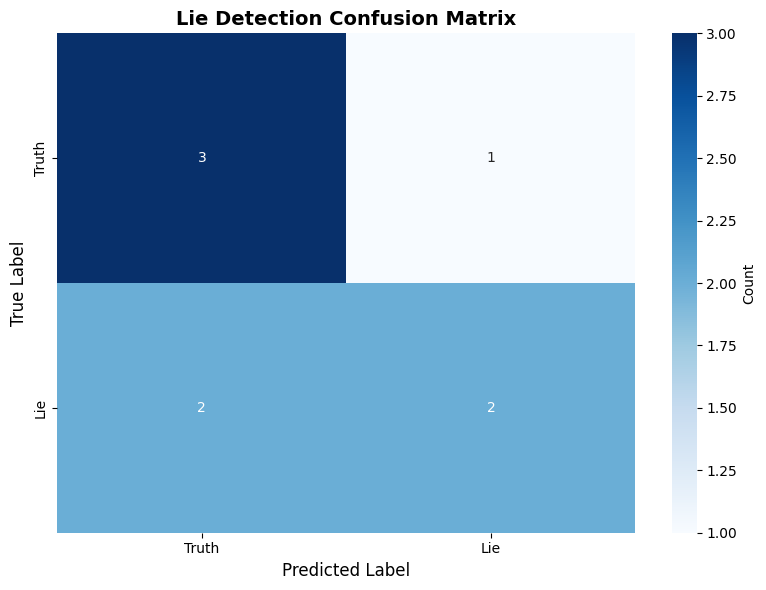

In [ ]:
import os, random
import numpy as np
import torch

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

import pandas as pd
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# ---------------- DATA LOADING ----------------
def load_data_enhanced():
    stimuli_df = pd.read_excel('/content/Subject_Stimuli.xlsx')
    stimuli_df['label'] = stimuli_df['LIE/TRUTH'].astype(int)

    eeg_cols = ['EEG.AF3', 'EEG.T7', 'EEG.Pz', 'EEG.T8', 'EEG.AF4']
    all_segments = []

    for _, row in stimuli_df.iterrows():
        session = row['SESSION']

        if session == 'S1':
            eeg_df = pd.read_csv('/content/S10S1.csv')
        else:
            eeg_df = pd.read_csv('/content/S10S2.csv')

        eeg_data = eeg_df[eeg_cols].values
        stim1, stim2 = int(row['STIMULI 1']), int(row['STIMULI 2'])

        start_idx = max(0, (stim1 + stim2) * 25 - 150)
        end_idx = min(len(eeg_data), start_idx + 300)

        if end_idx - start_idx >= 100:
            segment = eeg_data[start_idx:end_idx]
            all_segments.append({'eeg': segment, 'label': row['label']})

    return pd.DataFrame(all_segments)

# ---------------- DATASET ----------------
class EEGDataset(Dataset):
    def __init__(self, eeg_data, labels, sequence_length=256):
        self.sequence_length = sequence_length
        scaler = StandardScaler()

        processed = []
        for seq in eeg_data:
            seq = scaler.fit_transform(seq.reshape(-1,5)).reshape(seq.shape)
            if len(seq) >= sequence_length:
                processed.append(seq[:sequence_length])
            else:
                pad = np.zeros((sequence_length,5))
                pad[:len(seq)] = seq
                processed.append(pad)

        self.data = np.array(processed, dtype=np.float32)
        self.labels = np.array(labels, dtype=np.int64)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return torch.FloatTensor(self.data[idx]), torch.tensor(self.labels[idx])

# ---------------- MODEL ----------------
class EnhancedCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(5,32,9,padding=4),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(4),

            nn.Conv1d(32,64,7,padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(4),

            nn.Conv1d(64,128,5,padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(16)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(128*16,128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128,2)
        )

    def forward(self,x):
        x = x.transpose(1,2)
        x = self.conv(x)
        x = self.fc(x)
        return x

# ----------- DATALOADER RANDOMNESS CONTROL ----------
def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

# ---------------- MAIN ----------------
df = load_data_enhanced()
print("Segments:", len(df))

X_train, X_temp, y_train, y_temp = train_test_split(
    df['eeg'].tolist(), df['label'].values,
    test_size=0.3, stratify=df['label'], random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5, stratify=y_temp, random_state=SEED
)

train_ds = EEGDataset(X_train,y_train)
val_ds = EEGDataset(X_val,y_val)

train_loader = DataLoader(train_ds,32,True,
                          worker_init_fn=seed_worker,
                          generator=g)

val_loader = DataLoader(val_ds,32,False,
                        worker_init_fn=seed_worker,
                        generator=g)

# ---------------- TRAIN ----------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = EnhancedCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.0005)

for epoch in range(50):
    model.train()
    for x,y in train_loader:
        x,y = x.to(device),y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x),y)
        loss.backward()
        optimizer.step()

# ---------------- TEST ----------------
model.eval()
preds,true = [],[]

# Test on validation set (as in original code)
with torch.no_grad():
    for x,y in val_loader:
        out = model(x.to(device))
        preds.extend(out.argmax(1).cpu().numpy())
        true.extend(y.numpy())

# Print metrics
cm = confusion_matrix(true, preds)
print("Confusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(true, preds))

# ---------------- CONFUSION MATRIX PLOT ----------------
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Truth', 'Lie'],
            yticklabels=['Truth', 'Lie'],
            cbar_kws={'label': 'Count'})
plt.title('Lie Detection Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()



S9S1-S9S2

Segments: 54
Confusion Matrix:
[[3 1]
 [2 2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.75      0.67         4
           1       0.67      0.50      0.57         4

    accuracy                           0.62         8
   macro avg       0.63      0.62      0.62         8
weighted avg       0.63      0.62      0.62         8



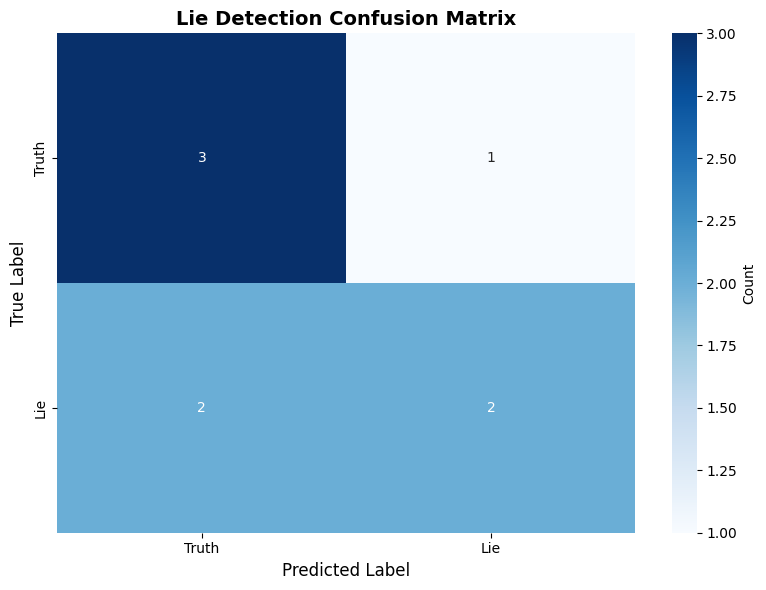

In [ ]:
import os, random
import numpy as np
import torch

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

import pandas as pd
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# ---------------- DATA LOADING ----------------
def load_data_enhanced():
    stimuli_df = pd.read_excel('/content/Subject_Stimuli.xlsx')
    stimuli_df['label'] = stimuli_df['LIE/TRUTH'].astype(int)

    eeg_cols = ['EEG.AF3', 'EEG.T7', 'EEG.Pz', 'EEG.T8', 'EEG.AF4']
    all_segments = []

    for _, row in stimuli_df.iterrows():
        session = row['SESSION']

        if session == 'S1':
            eeg_df = pd.read_csv('/content/S9S1.csv')
        else:
            eeg_df = pd.read_csv('/content/S9S2.csv')

        eeg_data = eeg_df[eeg_cols].values
        stim1, stim2 = int(row['STIMULI 1']), int(row['STIMULI 2'])

        start_idx = max(0, (stim1 + stim2) * 25 - 150)
        end_idx = min(len(eeg_data), start_idx + 300)

        if end_idx - start_idx >= 100:
            segment = eeg_data[start_idx:end_idx]
            all_segments.append({'eeg': segment, 'label': row['label']})

    return pd.DataFrame(all_segments)

# ---------------- DATASET ----------------
class EEGDataset(Dataset):
    def __init__(self, eeg_data, labels, sequence_length=256):
        self.sequence_length = sequence_length
        scaler = StandardScaler()

        processed = []
        for seq in eeg_data:
            seq = scaler.fit_transform(seq.reshape(-1,5)).reshape(seq.shape)
            if len(seq) >= sequence_length:
                processed.append(seq[:sequence_length])
            else:
                pad = np.zeros((sequence_length,5))
                pad[:len(seq)] = seq
                processed.append(pad)

        self.data = np.array(processed, dtype=np.float32)
        self.labels = np.array(labels, dtype=np.int64)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return torch.FloatTensor(self.data[idx]), torch.tensor(self.labels[idx])

# ---------------- MODEL ----------------
class EnhancedCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(5,32,9,padding=4),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(4),

            nn.Conv1d(32,64,7,padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(4),

            nn.Conv1d(64,128,5,padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(16)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(128*16,128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128,2)
        )

    def forward(self,x):
        x = x.transpose(1,2)
        x = self.conv(x)
        x = self.fc(x)
        return x

# ----------- DATALOADER RANDOMNESS CONTROL ----------
def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

# ---------------- MAIN ----------------
df = load_data_enhanced()
print("Segments:", len(df))

X_train, X_temp, y_train, y_temp = train_test_split(
    df['eeg'].tolist(), df['label'].values,
    test_size=0.3, stratify=df['label'], random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5, stratify=y_temp, random_state=SEED
)

train_ds = EEGDataset(X_train,y_train)
val_ds = EEGDataset(X_val,y_val)

train_loader = DataLoader(train_ds,32,True,
                          worker_init_fn=seed_worker,
                          generator=g)

val_loader = DataLoader(val_ds,32,False,
                        worker_init_fn=seed_worker,
                        generator=g)

# ---------------- TRAIN ----------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = EnhancedCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.0005)

for epoch in range(50):
    model.train()
    for x,y in train_loader:
        x,y = x.to(device),y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x),y)
        loss.backward()
        optimizer.step()

# ---------------- TEST ----------------
model.eval()
preds,true = [],[]

# Test on validation set
with torch.no_grad():
    for x,y in val_loader:
        out = model(x.to(device))
        preds.extend(out.argmax(1).cpu().numpy())
        true.extend(y.numpy())

# Print metrics
cm = confusion_matrix(true, preds)
print("Confusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(true, preds))

# ---------------- CONFUSION MATRIX PLOT ----------------
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Truth', 'Lie'],
            yticklabels=['Truth', 'Lie'],
            cbar_kws={'label': 'Count'})
plt.title('Lie Detection Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()


S8S1-S8S2

Segments: 54
Confusion Matrix:
[[3 1]
 [2 2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.75      0.67         4
           1       0.67      0.50      0.57         4

    accuracy                           0.62         8
   macro avg       0.63      0.62      0.62         8
weighted avg       0.63      0.62      0.62         8



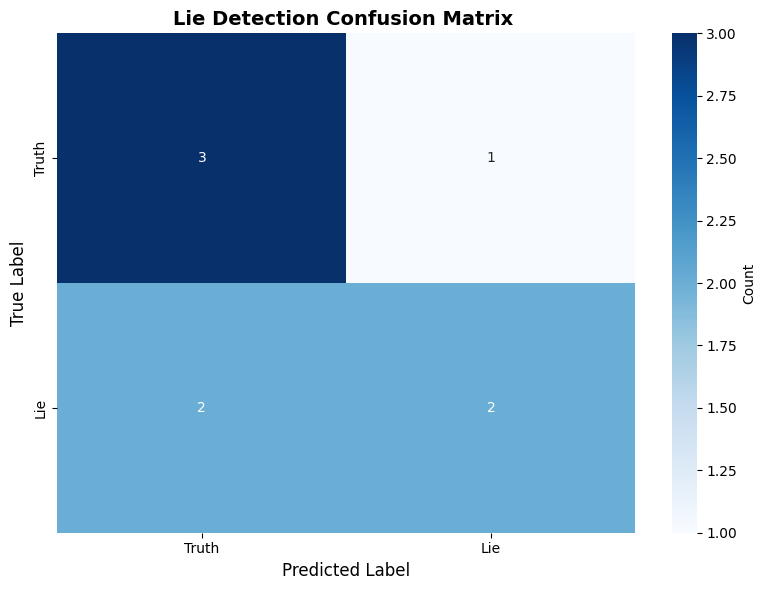

In [ ]:
import os, random
import numpy as np
import torch

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

import pandas as pd
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# ---------------- DATA LOADING ----------------
def load_data_enhanced():
    stimuli_df = pd.read_excel('/content/Subject_Stimuli.xlsx')
    stimuli_df['label'] = stimuli_df['LIE/TRUTH'].astype(int)

    eeg_cols = ['EEG.AF3', 'EEG.T7', 'EEG.Pz', 'EEG.T8', 'EEG.AF4']
    all_segments = []

    for _, row in stimuli_df.iterrows():
        session = row['SESSION']

        if session == 'S1':
            eeg_df = pd.read_csv('/content/S8S1.csv')
        else:
            eeg_df = pd.read_csv('/content/S8S2.csv')

        eeg_data = eeg_df[eeg_cols].values
        stim1, stim2 = int(row['STIMULI 1']), int(row['STIMULI 2'])

        start_idx = max(0, (stim1 + stim2) * 25 - 150)
        end_idx = min(len(eeg_data), start_idx + 300)

        if end_idx - start_idx >= 100:
            segment = eeg_data[start_idx:end_idx]
            all_segments.append({'eeg': segment, 'label': row['label']})

    return pd.DataFrame(all_segments)

# ---------------- DATASET ----------------
class EEGDataset(Dataset):
    def __init__(self, eeg_data, labels, sequence_length=256):
        self.sequence_length = sequence_length
        scaler = StandardScaler()

        processed = []
        for seq in eeg_data:
            seq = scaler.fit_transform(seq.reshape(-1,5)).reshape(seq.shape)
            if len(seq) >= sequence_length:
                processed.append(seq[:sequence_length])
            else:
                pad = np.zeros((sequence_length,5))
                pad[:len(seq)] = seq
                processed.append(pad)

        self.data = np.array(processed, dtype=np.float32)
        self.labels = np.array(labels, dtype=np.int64)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return torch.FloatTensor(self.data[idx]), torch.tensor(self.labels[idx])

# ---------------- MODEL ----------------
class EnhancedCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(5,32,9,padding=4),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(4),

            nn.Conv1d(32,64,7,padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(4),

            nn.Conv1d(64,128,5,padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(16)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(128*16,128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128,2)
        )

    def forward(self,x):
        x = x.transpose(1,2)
        x = self.conv(x)
        x = self.fc(x)
        return x

# ----------- DATALOADER RANDOMNESS CONTROL ----------
def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

# ---------------- MAIN ----------------
df = load_data_enhanced()
print("Segments:", len(df))

X_train, X_temp, y_train, y_temp = train_test_split(
    df['eeg'].tolist(), df['label'].values,
    test_size=0.3, stratify=df['label'], random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5, stratify=y_temp, random_state=SEED
)

train_ds = EEGDataset(X_train,y_train)
val_ds = EEGDataset(X_val,y_val)

train_loader = DataLoader(train_ds,32,True,
                          worker_init_fn=seed_worker,
                          generator=g)

val_loader = DataLoader(val_ds,32,False,
                        worker_init_fn=seed_worker,
                        generator=g)

# ---------------- TRAIN ----------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = EnhancedCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.0005)

for epoch in range(50):
    model.train()
    for x,y in train_loader:
        x,y = x.to(device),y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x),y)
        loss.backward()
        optimizer.step()

# ---------------- TEST ----------------
model.eval()
preds,true = [],[]

# Test on validation set
with torch.no_grad():
    for x,y in val_loader:
        out = model(x.to(device))
        preds.extend(out.argmax(1).cpu().numpy())
        true.extend(y.numpy())

# Print metrics
cm = confusion_matrix(true, preds)
print("Confusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(true, preds))

# ---------------- CONFUSION MATRIX PLOT ----------------
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Truth', 'Lie'],
            yticklabels=['Truth', 'Lie'],
            cbar_kws={'label': 'Count'})
plt.title('Lie Detection Confusion Matrix ', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()


S7S1-S7S2

Segments: 54
Confusion Matrix:
[[3 1]
 [2 2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.75      0.67         4
           1       0.67      0.50      0.57         4

    accuracy                           0.62         8
   macro avg       0.63      0.62      0.62         8
weighted avg       0.63      0.62      0.62         8



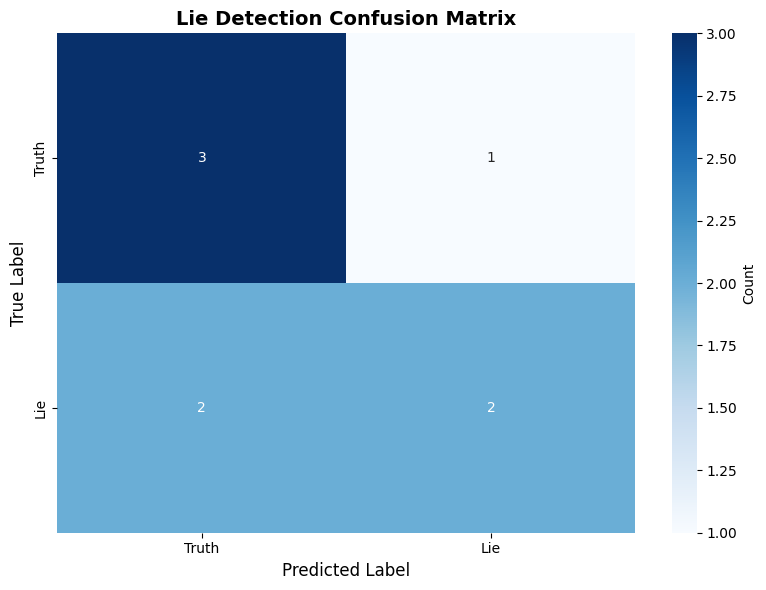

In [ ]:
import os, random
import numpy as np
import torch

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

import pandas as pd
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# ---------------- DATA LOADING ----------------
def load_data_enhanced():
    stimuli_df = pd.read_excel('/content/Subject_Stimuli.xlsx')
    stimuli_df['label'] = stimuli_df['LIE/TRUTH'].astype(int)

    eeg_cols = ['EEG.AF3', 'EEG.T7', 'EEG.Pz', 'EEG.T8', 'EEG.AF4']
    all_segments = []

    for _, row in stimuli_df.iterrows():
        session = row['SESSION']

        if session == 'S1':
            eeg_df = pd.read_csv('/content/S7S1.csv')
        else:
            eeg_df = pd.read_csv('/content/S7S2.csv')

        eeg_data = eeg_df[eeg_cols].values
        stim1, stim2 = int(row['STIMULI 1']), int(row['STIMULI 2'])

        start_idx = max(0, (stim1 + stim2) * 25 - 150)
        end_idx = min(len(eeg_data), start_idx + 300)

        if end_idx - start_idx >= 100:
            segment = eeg_data[start_idx:end_idx]
            all_segments.append({'eeg': segment, 'label': row['label']})

    return pd.DataFrame(all_segments)

# ---------------- DATASET ----------------
class EEGDataset(Dataset):
    def __init__(self, eeg_data, labels, sequence_length=256):
        self.sequence_length = sequence_length
        scaler = StandardScaler()

        processed = []
        for seq in eeg_data:
            seq = scaler.fit_transform(seq.reshape(-1,5)).reshape(seq.shape)
            if len(seq) >= sequence_length:
                processed.append(seq[:sequence_length])
            else:
                pad = np.zeros((sequence_length,5))
                pad[:len(seq)] = seq
                processed.append(pad)

        self.data = np.array(processed, dtype=np.float32)
        self.labels = np.array(labels, dtype=np.int64)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return torch.FloatTensor(self.data[idx]), torch.tensor(self.labels[idx])

# ---------------- MODEL ----------------
class EnhancedCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(5,32,9,padding=4),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(4),

            nn.Conv1d(32,64,7,padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(4),

            nn.Conv1d(64,128,5,padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(16)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(128*16,128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128,2)
        )

    def forward(self,x):
        x = x.transpose(1,2)
        x = self.conv(x)
        x = self.fc(x)
        return x

# ----------- DATALOADER RANDOMNESS CONTROL ----------
def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

# ---------------- MAIN ----------------
df = load_data_enhanced()
print("Segments:", len(df))

X_train, X_temp, y_train, y_temp = train_test_split(
    df['eeg'].tolist(), df['label'].values,
    test_size=0.3, stratify=df['label'], random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5, stratify=y_temp, random_state=SEED
)

train_ds = EEGDataset(X_train,y_train)
val_ds = EEGDataset(X_val,y_val)

train_loader = DataLoader(train_ds,32,True,
                          worker_init_fn=seed_worker,
                          generator=g)

val_loader = DataLoader(val_ds,32,False,
                        worker_init_fn=seed_worker,
                        generator=g)

# ---------------- TRAIN ----------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = EnhancedCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.0005)

for epoch in range(50):
    model.train()
    for x,y in train_loader:
        x,y = x.to(device),y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x),y)
        loss.backward()
        optimizer.step()

# ---------------- TEST ----------------
model.eval()
preds,true = [],[]

# Test on validation set
with torch.no_grad():
    for x,y in val_loader:
        out = model(x.to(device))
        preds.extend(out.argmax(1).cpu().numpy())
        true.extend(y.numpy())

# Print metrics
cm = confusion_matrix(true, preds)
print("Confusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(true, preds))

# ---------------- CONFUSION MATRIX PLOT ----------------
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Truth', 'Lie'],
            yticklabels=['Truth', 'Lie'],
            cbar_kws={'label': 'Count'})
plt.title('Lie Detection Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()


S19S1-S19S2

Segments: 54
Confusion Matrix:
[[3 1]
 [2 2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.75      0.67         4
           1       0.67      0.50      0.57         4

    accuracy                           0.62         8
   macro avg       0.63      0.62      0.62         8
weighted avg       0.63      0.62      0.62         8



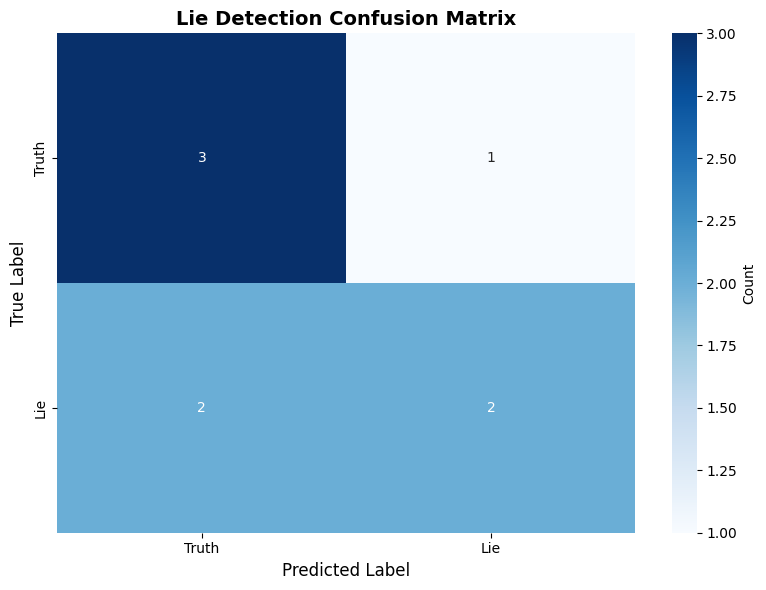

In [ ]:
import os, random
import numpy as np
import torch

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

import pandas as pd
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# ---------------- DATA LOADING ----------------
def load_data_enhanced():
    stimuli_df = pd.read_excel('/content/Subject_Stimuli.xlsx')
    stimuli_df['label'] = stimuli_df['LIE/TRUTH'].astype(int)

    eeg_cols = ['EEG.AF3', 'EEG.T7', 'EEG.Pz', 'EEG.T8', 'EEG.AF4']
    all_segments = []

    for _, row in stimuli_df.iterrows():
        session = row['SESSION']

        if session == 'S1':
            eeg_df = pd.read_csv('/content/S19S1.csv')
        else:
            eeg_df = pd.read_csv('/content/S19S2.csv')

        eeg_data = eeg_df[eeg_cols].values
        stim1, stim2 = int(row['STIMULI 1']), int(row['STIMULI 2'])

        start_idx = max(0, (stim1 + stim2) * 25 - 150)
        end_idx = min(len(eeg_data), start_idx + 300)

        if end_idx - start_idx >= 100:
            segment = eeg_data[start_idx:end_idx]
            all_segments.append({'eeg': segment, 'label': row['label']})

    return pd.DataFrame(all_segments)

# ---------------- DATASET ----------------
class EEGDataset(Dataset):
    def __init__(self, eeg_data, labels, sequence_length=256):
        self.sequence_length = sequence_length
        scaler = StandardScaler()

        processed = []
        for seq in eeg_data:
            seq = scaler.fit_transform(seq.reshape(-1,5)).reshape(seq.shape)
            if len(seq) >= sequence_length:
                processed.append(seq[:sequence_length])
            else:
                pad = np.zeros((sequence_length,5))
                pad[:len(seq)] = seq
                processed.append(pad)

        self.data = np.array(processed, dtype=np.float32)
        self.labels = np.array(labels, dtype=np.int64)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return torch.FloatTensor(self.data[idx]), torch.tensor(self.labels[idx])

# ---------------- MODEL ----------------
class EnhancedCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(5,32,9,padding=4),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(4),

            nn.Conv1d(32,64,7,padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(4),

            nn.Conv1d(64,128,5,padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(16)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(128*16,128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128,2)
        )

    def forward(self,x):
        x = x.transpose(1,2)
        x = self.conv(x)
        x = self.fc(x)
        return x

# ----------- DATALOADER RANDOMNESS CONTROL ----------
def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

# ---------------- MAIN ----------------
df = load_data_enhanced()
print("Segments:", len(df))

X_train, X_temp, y_train, y_temp = train_test_split(
    df['eeg'].tolist(), df['label'].values,
    test_size=0.3, stratify=df['label'], random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5, stratify=y_temp, random_state=SEED
)

train_ds = EEGDataset(X_train,y_train)
val_ds = EEGDataset(X_val,y_val)

train_loader = DataLoader(train_ds,32,True,
                          worker_init_fn=seed_worker,
                          generator=g)

val_loader = DataLoader(val_ds,32,False,
                        worker_init_fn=seed_worker,
                        generator=g)

# ---------------- TRAIN ----------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = EnhancedCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.0005)

for epoch in range(50):
    model.train()
    for x,y in train_loader:
        x,y = x.to(device),y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x),y)
        loss.backward()
        optimizer.step()

# ---------------- TEST ----------------
model.eval()
preds,true = [],[]

# Test on validation set
with torch.no_grad():
    for x,y in val_loader:
        out = model(x.to(device))
        preds.extend(out.argmax(1).cpu().numpy())
        true.extend(y.numpy())

# Print metrics
cm = confusion_matrix(true, preds)
print("Confusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(true, preds))

# ---------------- CONFUSION MATRIX PLOT ----------------
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Truth', 'Lie'],
            yticklabels=['Truth', 'Lie'],
            cbar_kws={'label': 'Count'})
plt.title('Lie Detection Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

## LSTM

S10S1-S10S2

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from torch.utils.data import DataLoader, TensorDataset
import random

# ==========================================================
# 1️⃣ SEED FOR REPRODUCIBILITY
# ==========================================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# ==========================================================
# 2️⃣ LOAD DATA
# ==========================================================

df1 = pd.read_csv("/content/S10S1.csv")
df2 = pd.read_csv("/content/S10S2.csv")
stimuli = pd.read_excel("/content/Subject_Stimuli.xlsx")

df = pd.concat([df1, df2], ignore_index=True)

print("Combined EEG Shape:", df.shape)

# ==========================================================
# 3️⃣ SLIDING WINDOW SEGMENTATION
# ==========================================================

window_size = 120
stride = 60

total_samples = len(df)
num_trials = len(stimuli)
samples_per_trial = total_samples // num_trials

X_windows = []
y_windows = []

for i in range(num_trials):
    start_trial = i * samples_per_trial
    end_trial = start_trial + samples_per_trial

    trial_data = df.iloc[start_trial:end_trial].values
    label = stimuli["LIE/TRUTH"].iloc[i]

    for start in range(0, len(trial_data) - window_size, stride):
        end = start + window_size
        X_windows.append(trial_data[start:end])
        y_windows.append(label)

X = np.array(X_windows)
y = np.array(y_windows)

print("Dataset Shape:", X.shape)

# ==========================================================
# 4️⃣ NORMALIZATION
# ==========================================================

scaler = StandardScaler()
X_reshaped = X.reshape(-1, X.shape[2])
X_scaled = scaler.fit_transform(X_reshaped)
X = X_scaled.reshape(X.shape)

# ==========================================================
# 5️⃣ TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=16, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=16)

# ==========================================================
# 6️⃣ STANDARD LSTM MODEL
# ==========================================================

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(LSTMModel, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            dropout=0.4,
            bidirectional=False
        )

        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

model = LSTMModel(input_size=5, hidden_size=128, num_classes=2)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)

# ==========================================================
# 7️⃣ TRAINING
# ==========================================================

epochs = 100

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for xb, yb in train_loader:
        outputs = model(xb)
        loss = criterion(outputs, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}")

# ==========================================================
# 8️⃣ EVALUATION
# ==========================================================

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for xb, yb in test_loader:
        outputs = model(xb)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.numpy())
        all_labels.extend(yb.numpy())

accuracy = accuracy_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)

print("\n" + "="*60)
print("EEG LSTM LIE DETECTOR RESULTS")
print("="*60)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(all_labels, all_preds))

print("Final Accuracy:", round(accuracy, 4))

Combined EEG Shape: (19200, 5)
Dataset Shape: (216, 120, 5)
Epoch 10/100, Loss: 7.2053
Epoch 20/100, Loss: 6.7762
Epoch 30/100, Loss: 6.6721
Epoch 40/100, Loss: 6.2287
Epoch 50/100, Loss: 5.7890
Epoch 60/100, Loss: 4.6115
Epoch 70/100, Loss: 3.8692
Epoch 80/100, Loss: 1.8085
Epoch 90/100, Loss: 4.3524
Epoch 100/100, Loss: 2.1860

EEG LSTM LIE DETECTOR RESULTS

Confusion Matrix:
[[13  9]
 [11 11]]

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.59      0.57        22
           1       0.55      0.50      0.52        22

    accuracy                           0.55        44
   macro avg       0.55      0.55      0.54        44
weighted avg       0.55      0.55      0.54        44

Final Accuracy: 0.5455


S9S1-S9S2

In [ ]:

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from torch.utils.data import DataLoader, TensorDataset
import random

# ==========================================================
# 1️⃣ SEED FOR REPRODUCIBILITY
# ==========================================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# ==========================================================
# 2️⃣ LOAD DATA
# ==========================================================

df1 = pd.read_csv("/content/S9S1.csv")
df2 = pd.read_csv("/content/S9S2.csv")
stimuli = pd.read_excel("/content/Subject_Stimuli.xlsx")

df = pd.concat([df1, df2], ignore_index=True)

print("Combined EEG Shape:", df.shape)

# ==========================================================
# 3️⃣ SLIDING WINDOW SEGMENTATION
# ==========================================================

window_size = 120
stride = 60

total_samples = len(df)
num_trials = len(stimuli)
samples_per_trial = total_samples // num_trials

X_windows = []
y_windows = []

for i in range(num_trials):
    start_trial = i * samples_per_trial
    end_trial = start_trial + samples_per_trial

    trial_data = df.iloc[start_trial:end_trial].values
    label = stimuli["LIE/TRUTH"].iloc[i]

    for start in range(0, len(trial_data) - window_size, stride):
        end = start + window_size
        X_windows.append(trial_data[start:end])
        y_windows.append(label)

X = np.array(X_windows)
y = np.array(y_windows)

print("Dataset Shape:", X.shape)

# ==========================================================
# 4️⃣ NORMALIZATION
# ==========================================================

scaler = StandardScaler()
X_reshaped = X.reshape(-1, X.shape[2])
X_scaled = scaler.fit_transform(X_reshaped)
X = X_scaled.reshape(X.shape)

# ==========================================================
# 5️⃣ TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=16, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=16)

# ==========================================================
# 6️⃣ STANDARD LSTM MODEL
# ==========================================================

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(LSTMModel, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            dropout=0.4,
            bidirectional=False
        )

        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

model = LSTMModel(input_size=5, hidden_size=128, num_classes=2)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)

# ==========================================================
# 7️⃣ TRAINING
# ==========================================================

epochs = 100

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for xb, yb in train_loader:
        outputs = model(xb)
        loss = criterion(outputs, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}")

# ==========================================================
# 8️⃣ EVALUATION
# ==========================================================

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for xb, yb in test_loader:
        outputs = model(xb)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.numpy())
        all_labels.extend(yb.numpy())

accuracy = accuracy_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)

print("\n" + "="*60)
print("EEG LSTM LIE DETECTOR RESULTS")
print("="*60)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(all_labels, all_preds))

print("Final Accuracy:", round(accuracy, 4))

Combined EEG Shape: (19200, 5)
Dataset Shape: (216, 120, 5)
Epoch 10/100, Loss: 7.3749
Epoch 20/100, Loss: 7.1999
Epoch 30/100, Loss: 6.8588
Epoch 40/100, Loss: 6.6485
Epoch 50/100, Loss: 6.1999
Epoch 60/100, Loss: 5.8592
Epoch 70/100, Loss: 5.6407
Epoch 80/100, Loss: 4.9190
Epoch 90/100, Loss: 5.7824
Epoch 100/100, Loss: 4.5623

EEG LSTM LIE DETECTOR RESULTS

Confusion Matrix:
[[17  5]
 [20  2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.46      0.77      0.58        22
           1       0.29      0.09      0.14        22

    accuracy                           0.43        44
   macro avg       0.37      0.43      0.36        44
weighted avg       0.37      0.43      0.36        44

Final Accuracy: 0.4318


S8S1-S8S2

In [ ]:
# ==========================================================
# EEG LIE DETECTION – LSTM
# ==========================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from torch.utils.data import DataLoader, TensorDataset
import random

# ==========================================================
# 1️⃣ SEED FOR REPRODUCIBILITY
# ==========================================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# ==========================================================
# 2️⃣ LOAD DATA
# ==========================================================

df1 = pd.read_csv("/content/S8S1.csv")
df2 = pd.read_csv("/content/S8S2.csv")
stimuli = pd.read_excel("/content/Subject_Stimuli.xlsx")

df = pd.concat([df1, df2], ignore_index=True)

print("Combined EEG Shape:", df.shape)

# ==========================================================
# 3️⃣ SLIDING WINDOW SEGMENTATION
# ==========================================================

window_size = 120
stride = 60

total_samples = len(df)
num_trials = len(stimuli)
samples_per_trial = total_samples // num_trials

X_windows = []
y_windows = []

for i in range(num_trials):
    start_trial = i * samples_per_trial
    end_trial = start_trial + samples_per_trial

    trial_data = df.iloc[start_trial:end_trial].values
    label = stimuli["LIE/TRUTH"].iloc[i]

    for start in range(0, len(trial_data) - window_size, stride):
        end = start + window_size
        X_windows.append(trial_data[start:end])
        y_windows.append(label)

X = np.array(X_windows)
y = np.array(y_windows)

print("Dataset Shape:", X.shape)

# ==========================================================
# 4️⃣ NORMALIZATION
# ==========================================================

scaler = StandardScaler()
X_reshaped = X.reshape(-1, X.shape[2])
X_scaled = scaler.fit_transform(X_reshaped)
X = X_scaled.reshape(X.shape)

# ==========================================================
# 5️⃣ TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=16, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=16)

# ==========================================================
# 6️⃣ STANDARD LSTM MODEL
# ==========================================================

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(LSTMModel, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            dropout=0.4,
            bidirectional=False
        )

        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

model = LSTMModel(input_size=5, hidden_size=128, num_classes=2)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)

# ==========================================================
# 7️⃣ TRAINING
# ==========================================================

epochs = 100

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for xb, yb in train_loader:
        outputs = model(xb)
        loss = criterion(outputs, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}")

# ==========================================================
# 8️⃣ EVALUATION
# ==========================================================

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for xb, yb in test_loader:
        outputs = model(xb)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.numpy())
        all_labels.extend(yb.numpy())

accuracy = accuracy_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)

print("\n" + "="*60)
print("EEG LSTM LIE DETECTOR RESULTS")
print("="*60)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(all_labels, all_preds))

print("Final Accuracy:", round(accuracy, 4))

Combined EEG Shape: (19200, 5)
Dataset Shape: (216, 120, 5)
Epoch 10/100, Loss: 7.3402
Epoch 20/100, Loss: 6.7804
Epoch 30/100, Loss: 6.4241
Epoch 40/100, Loss: 6.3238
Epoch 50/100, Loss: 6.2423
Epoch 60/100, Loss: 5.7292
Epoch 70/100, Loss: 5.1267
Epoch 80/100, Loss: 3.8502
Epoch 90/100, Loss: 5.5033
Epoch 100/100, Loss: 2.2017

EEG LSTM LIE DETECTOR RESULTS

Confusion Matrix:
[[ 8 14]
 [14  8]]

Classification Report:
              precision    recall  f1-score   support

           0       0.36      0.36      0.36        22
           1       0.36      0.36      0.36        22

    accuracy                           0.36        44
   macro avg       0.36      0.36      0.36        44
weighted avg       0.36      0.36      0.36        44

Final Accuracy: 0.3636


S7S1-S7S2

In [ ]:
# ==========================================================
# EEG LIE DETECTION – LSTM (NOT BiLSTM)
# ==========================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from torch.utils.data import DataLoader, TensorDataset
import random

# ==========================================================
# 1️⃣ SEED FOR REPRODUCIBILITY
# ==========================================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# ==========================================================
# 2️⃣ LOAD DATA
# ==========================================================

df1 = pd.read_csv("/content/S7S1.csv")
df2 = pd.read_csv("/content/S7S2.csv")
stimuli = pd.read_excel("/content/Subject_Stimuli.xlsx")

df = pd.concat([df1, df2], ignore_index=True)

print("Combined EEG Shape:", df.shape)

# ==========================================================
# 3️⃣ SLIDING WINDOW SEGMENTATION
# ==========================================================

window_size = 120
stride = 60

total_samples = len(df)
num_trials = len(stimuli)
samples_per_trial = total_samples // num_trials

X_windows = []
y_windows = []

for i in range(num_trials):
    start_trial = i * samples_per_trial
    end_trial = start_trial + samples_per_trial

    trial_data = df.iloc[start_trial:end_trial].values
    label = stimuli["LIE/TRUTH"].iloc[i]

    for start in range(0, len(trial_data) - window_size, stride):
        end = start + window_size
        X_windows.append(trial_data[start:end])
        y_windows.append(label)

X = np.array(X_windows)
y = np.array(y_windows)

print("Dataset Shape:", X.shape)

# ==========================================================
# 4️⃣ NORMALIZATION
# ==========================================================

scaler = StandardScaler()
X_reshaped = X.reshape(-1, X.shape[2])
X_scaled = scaler.fit_transform(X_reshaped)
X = X_scaled.reshape(X.shape)

# ==========================================================
# 5️⃣ TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=16, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=16)

# ==========================================================
# 6️⃣ STANDARD LSTM MODEL
# ==========================================================

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(LSTMModel, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            dropout=0.4,
            bidirectional=False
        )

        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

model = LSTMModel(input_size=5, hidden_size=128, num_classes=2)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)

# ==========================================================
# 7️⃣ TRAINING
# ==========================================================

epochs = 100

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for xb, yb in train_loader:
        outputs = model(xb)
        loss = criterion(outputs, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}")

# ==========================================================
# 8️⃣ EVALUATION
# ==========================================================

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for xb, yb in test_loader:
        outputs = model(xb)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.numpy())
        all_labels.extend(yb.numpy())

accuracy = accuracy_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)

print("\n" + "="*60)
print("EEG LSTM LIE DETECTOR RESULTS")
print("="*60)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(all_labels, all_preds))

print("Final Accuracy:", round(accuracy, 4))

Combined EEG Shape: (19200, 5)
Dataset Shape: (216, 120, 5)
Epoch 10/100, Loss: 7.5415
Epoch 20/100, Loss: 6.9677
Epoch 30/100, Loss: 6.2412
Epoch 40/100, Loss: 6.2376
Epoch 50/100, Loss: 5.1020
Epoch 60/100, Loss: 5.5571
Epoch 70/100, Loss: 5.0565
Epoch 80/100, Loss: 4.2263
Epoch 90/100, Loss: 4.4868
Epoch 100/100, Loss: 3.7272

EEG LSTM LIE DETECTOR RESULTS

Confusion Matrix:
[[ 7 15]
 [ 6 16]]

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.32      0.40        22
           1       0.52      0.73      0.60        22

    accuracy                           0.52        44
   macro avg       0.53      0.52      0.50        44
weighted avg       0.53      0.52      0.50        44

Final Accuracy: 0.5227


S19S1-S19S2

In [ ]:
# ==========================================================
# EEG LIE DETECTION – LSTM (NOT BiLSTM)
# ==========================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from torch.utils.data import DataLoader, TensorDataset
import random

# ==========================================================
# 1️⃣ SEED FOR REPRODUCIBILITY
# ==========================================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# ==========================================================
# 2️⃣ LOAD DATA
# ==========================================================

df1 = pd.read_csv("/content/S19S1.csv")
df2 = pd.read_csv("/content/S19S2.csv")
stimuli = pd.read_excel("/content/Subject_Stimuli.xlsx")

df = pd.concat([df1, df2], ignore_index=True)

print("Combined EEG Shape:", df.shape)

# ==========================================================
# 3️⃣ SLIDING WINDOW SEGMENTATION
# ==========================================================

window_size = 120
stride = 60

total_samples = len(df)
num_trials = len(stimuli)
samples_per_trial = total_samples // num_trials

X_windows = []
y_windows = []

for i in range(num_trials):
    start_trial = i * samples_per_trial
    end_trial = start_trial + samples_per_trial

    trial_data = df.iloc[start_trial:end_trial].values
    label = stimuli["LIE/TRUTH"].iloc[i]

    for start in range(0, len(trial_data) - window_size, stride):
        end = start + window_size
        X_windows.append(trial_data[start:end])
        y_windows.append(label)

X = np.array(X_windows)
y = np.array(y_windows)

print("Dataset Shape:", X.shape)

# ==========================================================
# 4️⃣ NORMALIZATION
# ==========================================================

scaler = StandardScaler()
X_reshaped = X.reshape(-1, X.shape[2])
X_scaled = scaler.fit_transform(X_reshaped)
X = X_scaled.reshape(X.shape)

# ==========================================================
# 5️⃣ TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=16, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=16)

# ==========================================================
# 6️⃣ STANDARD LSTM MODEL
# ==========================================================

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(LSTMModel, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            dropout=0.4,
            bidirectional=False
        )

        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

model = LSTMModel(input_size=5, hidden_size=128, num_classes=2)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)

# ==========================================================
# 7️⃣ TRAINING
# ==========================================================

epochs = 100

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for xb, yb in train_loader:
        outputs = model(xb)
        loss = criterion(outputs, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}")

# ==========================================================
# 8️⃣ EVALUATION
# ==========================================================

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for xb, yb in test_loader:
        outputs = model(xb)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.numpy())
        all_labels.extend(yb.numpy())

accuracy = accuracy_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)

print("\n" + "="*60)
print("EEG LSTM LIE DETECTOR RESULTS")
print("="*60)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(all_labels, all_preds))

print("Final Accuracy:", round(accuracy, 4))

Combined EEG Shape: (19200, 5)
Dataset Shape: (216, 120, 5)
Epoch 10/100, Loss: 6.8590
Epoch 20/100, Loss: 6.3164
Epoch 30/100, Loss: 5.3562
Epoch 40/100, Loss: 5.5041
Epoch 50/100, Loss: 5.8125
Epoch 60/100, Loss: 6.0402
Epoch 70/100, Loss: 4.3677
Epoch 80/100, Loss: 4.7450
Epoch 90/100, Loss: 3.5711
Epoch 100/100, Loss: 3.0723

EEG LSTM LIE DETECTOR RESULTS

Confusion Matrix:
[[12 10]
 [14  8]]

Classification Report:
              precision    recall  f1-score   support

           0       0.46      0.55      0.50        22
           1       0.44      0.36      0.40        22

    accuracy                           0.45        44
   macro avg       0.45      0.45      0.45        44
weighted avg       0.45      0.45      0.45        44

Final Accuracy: 0.4545


BI-LSTM

S10S1-S10S2

In [ ]:
import os, random
import numpy as np
import tensorflow as tf

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout, BatchNormalization, GaussianNoise
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# LOAD LABELS
stim_df = pd.read_excel('/content/Subject_Stimuli.xlsx')
s10_rows = stim_df[(stim_df['SUBJECT'] == 'S10')]
s1_label = int(s10_rows[s10_rows['SESSION'] == 'S1']['LIE/TRUTH'].values[0])
s2_label = int(s10_rows[s10_rows['SESSION'] == 'S2']['LIE/TRUTH'].values[0])

channels = ['EEG.AF3', 'EEG.T7', 'EEG.Pz', 'EEG.T8', 'EEG.AF4']

sequence_length = 64
step = 8
max_samples_per_class = 4000

# SCALER
sample_data = pd.read_csv('/content/S10S1.csv', nrows=20000, header=0, names=channels)
scaler = StandardScaler().fit(sample_data[channels])

def eeg_generator(filename, label):
    data = pd.read_csv(filename, header=0, names=channels)
    data = scaler.transform(data.fillna(0))

    X, y = [], []
    for i in range(0, len(data)-sequence_length, step):
        X.append(data[i:i+sequence_length])
        y.append(label)
        if len(X) >= max_samples_per_class:
            break

    return np.array(X), np.array(y)

X1, y1 = eeg_generator('/content/S10S1.csv', s1_label)
X2, y2 = eeg_generator('/content/S10S2.csv', s2_label)

X = np.concatenate([X1, X2])
y = np.concatenate([y1, y2])

y_cat = to_categorical(y, 2)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, stratify=y, random_state=SEED
)

# SMALLER MODEL
model = Sequential([
    GaussianNoise(0.3, input_shape=(sequence_length, len(channels))),

    Bidirectional(LSTM(16, return_sequences=True)),
    BatchNormalization(),
    Dropout(0.6),

    Bidirectional(LSTM(8)),
    BatchNormalization(),
    Dropout(0.6),

    Dense(8, activation='relu'),
    Dropout(0.5),

    Dense(2, activation='softmax')
])

loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.2)

model.compile(
    optimizer='adam',
    loss=loss_fn,
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True)
]

history = model.fit(
    X_train, y_train,
    epochs=12,
    batch_size=256,
    validation_split=0.2,
    callbacks=callbacks
)

# TEST
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred_classes))

print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/regularization/gaussian_noise.py:29: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/12
6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 312ms/step - accuracy: 0.5027 - loss: 1.3134 - precision: 0.5029 - recall: 0.4881 - val_accuracy: 0.5052 - val_loss: 0.6925 - val_precision: 0.5052 - val_recall: 0.5052
Epoch 2/12
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.5007 - loss: 1.1885 - precision: 0.5007 - recall: 0.5007 - val_accuracy: 0.5079 - val_loss: 0.6910 - val_precision: 0.5079 - val_recall: 0.5079
Epoch 3/12
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.5127 - loss: 1.2050 - precision: 0.5127 - recall: 0.5127 - val_accuracy: 0.5157 - val_loss: 0.6901 - val_precision: 0.5157 - val_recall: 0.5157
Epoch 4/12
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.5020 - loss: 1.1203 - precision: 0.5020 - recall: 0.5020 - val_accuracy: 0.5393 - val_loss: 0.6896 - val_precision: 0.5393 - val_recall: 0.5393
Epoch 5/12
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.5047 - loss: 1.0793 - precision: 0.5047 - recall: 0.5047 - val_accuracy: 0.5942 - val_loss: 0.6891 - val_pr

S9S1-S9S2

In [ ]:
import os, random
import numpy as np
import tensorflow as tf

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout, BatchNormalization, GaussianNoise
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# LOAD LABELS
stim_df = pd.read_excel('/content/Subject_Stimuli.xlsx')
s10_rows = stim_df[(stim_df['SUBJECT'] == 'S10')]
s1_label = int(s10_rows[s10_rows['SESSION'] == 'S1']['LIE/TRUTH'].values[0])
s2_label = int(s10_rows[s10_rows['SESSION'] == 'S2']['LIE/TRUTH'].values[0])

channels = ['EEG.AF3', 'EEG.T7', 'EEG.Pz', 'EEG.T8', 'EEG.AF4']

sequence_length = 64
step = 8
max_samples_per_class = 4000

# SCALER
sample_data = pd.read_csv('/content/S9S1.csv', nrows=20000, header=0, names=channels)
scaler = StandardScaler().fit(sample_data[channels])

def eeg_generator(filename, label):
    data = pd.read_csv(filename, header=0, names=channels)
    data = scaler.transform(data.fillna(0))

    X, y = [], []
    for i in range(0, len(data)-sequence_length, step):
        X.append(data[i:i+sequence_length])
        y.append(label)
        if len(X) >= max_samples_per_class:
            break

    return np.array(X), np.array(y)

X1, y1 = eeg_generator('/content/S9S1.csv', s1_label)
X2, y2 = eeg_generator('/content/S9S2.csv', s2_label)

X = np.concatenate([X1, X2])
y = np.concatenate([y1, y2])

y_cat = to_categorical(y, 2)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, stratify=y, random_state=SEED
)

# SMALLER MODEL
model = Sequential([
    GaussianNoise(0.3, input_shape=(sequence_length, len(channels))),

    Bidirectional(LSTM(16, return_sequences=True)),
    BatchNormalization(),
    Dropout(0.6),

    Bidirectional(LSTM(8)),
    BatchNormalization(),
    Dropout(0.6),

    Dense(8, activation='relu'),
    Dropout(0.5),

    Dense(2, activation='softmax')
])

loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.2)

model.compile(
    optimizer='adam',
    loss=loss_fn,
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True)
]

history = model.fit(
    X_train, y_train,
    epochs=12,
    batch_size=256,
    validation_split=0.2,
    callbacks=callbacks
)

# TEST
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred_classes))

print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/regularization/gaussian_noise.py:29: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/12
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 274ms/step - accuracy: 0.5020 - loss: 1.2927 - precision: 0.4998 - recall: 0.4844 - val_accuracy: 0.6204 - val_loss: 0.6858 - val_precision: 0.6204 - val_recall: 0.6204
Epoch 2/12
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.5114 - loss: 1.2326 - precision: 0.5114 - recall: 0.5114 - val_accuracy: 0.7487 - val_loss: 0.6839 - val_precision: 0.7487 - val_recall: 0.7487
Epoch 3/12
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.4913 - loss: 1.1920 - precision: 0.4913 - recall: 0.4913 - val_accuracy: 0.7356 - val_loss: 0.6823 - val_precision: 0.7356 - val_recall: 0.7356
Epoch 4/12
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.5268 - loss: 1.0399 - precision: 0.5268 - recall: 0.5268 - val_accuracy: 0.7094 - val_loss: 0.6805 - val_precision: 0.7094 - val_recall: 0.7094
Epoch 5/12
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.5324 - loss: 1.0323 - precision: 0.5324 - recall: 0.5324 - val_accuracy: 0.6623 - val_loss: 0.6792 - val_pr

S8S1-S8S2

In [ ]:
import os, random
import numpy as np
import tensorflow as tf

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout, BatchNormalization, GaussianNoise
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# LOAD LABELS
stim_df = pd.read_excel('/content/Subject_Stimuli.xlsx')
s10_rows = stim_df[(stim_df['SUBJECT'] == 'S10')]
s1_label = int(s10_rows[s10_rows['SESSION'] == 'S1']['LIE/TRUTH'].values[0])
s2_label = int(s10_rows[s10_rows['SESSION'] == 'S2']['LIE/TRUTH'].values[0])

channels = ['EEG.AF3', 'EEG.T7', 'EEG.Pz', 'EEG.T8', 'EEG.AF4']

sequence_length = 64
step = 8
max_samples_per_class = 4000

# SCALER
sample_data = pd.read_csv('/content/S8S1.csv', nrows=20000, header=0, names=channels)
scaler = StandardScaler().fit(sample_data[channels])

def eeg_generator(filename, label):
    data = pd.read_csv(filename, header=0, names=channels)
    data = scaler.transform(data.fillna(0))

    X, y = [], []
    for i in range(0, len(data)-sequence_length, step):
        X.append(data[i:i+sequence_length])
        y.append(label)
        if len(X) >= max_samples_per_class:
            break

    return np.array(X), np.array(y)

X1, y1 = eeg_generator('/content/S8S1.csv', s1_label)
X2, y2 = eeg_generator('/content/S8S2.csv', s2_label)

X = np.concatenate([X1, X2])
y = np.concatenate([y1, y2])

y_cat = to_categorical(y, 2)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, stratify=y, random_state=SEED
)

# SMALLER MODEL
model = Sequential([
    GaussianNoise(0.3, input_shape=(sequence_length, len(channels))),

    Bidirectional(LSTM(16, return_sequences=True)),
    BatchNormalization(),
    Dropout(0.6),

    Bidirectional(LSTM(8)),
    BatchNormalization(),
    Dropout(0.6),

    Dense(8, activation='relu'),
    Dropout(0.5),

    Dense(2, activation='softmax')
])

loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.2)

model.compile(
    optimizer='adam',
    loss=loss_fn,
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True)
]

history = model.fit(
    X_train, y_train,
    epochs=12,
    batch_size=256,
    validation_split=0.2,
    callbacks=callbacks
)

# TEST
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred_classes))

print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/regularization/gaussian_noise.py:29: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/12
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 379ms/step - accuracy: 0.4991 - loss: 1.3339 - precision: 0.4986 - recall: 0.4787 - val_accuracy: 0.4921 - val_loss: 0.7003 - val_precision: 0.4921 - val_recall: 0.4921
Epoch 2/12
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5242 - loss: 1.2558 - precision: 0.5242 - recall: 0.5242 - val_accuracy: 0.4660 - val_loss: 0.6987 - val_precision: 0.4660 - val_recall: 0.4660
Epoch 3/12
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.4930 - loss: 1.2242 - precision: 0.4930 - recall: 0.4930 - val_accuracy: 0.4712 - val_loss: 0.6975 - val_precision: 0.4712 - val_recall: 0.4712
Epoch 4/12
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5142 - loss: 1.1574 - precision: 0.5142 - recall: 0.5142 - val_accuracy: 0.4634 - val_loss: 0.6967 - val_precision: 0.4634 - val_recall: 0.4634
Epoch 5/12
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4992 - loss: 1.1618 - precision: 0.4992 - recall: 0.4992 - val_accuracy: 0.4398 - val_loss: 0.6963 - val_pre

S7S1-S7S2

In [ ]:
import os, random
import numpy as np
import tensorflow as tf

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout, BatchNormalization, GaussianNoise
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# LOAD LABELS
stim_df = pd.read_excel('/content/Subject_Stimuli.xlsx')
s10_rows = stim_df[(stim_df['SUBJECT'] == 'S10')]
s1_label = int(s10_rows[s10_rows['SESSION'] == 'S1']['LIE/TRUTH'].values[0])
s2_label = int(s10_rows[s10_rows['SESSION'] == 'S2']['LIE/TRUTH'].values[0])

channels = ['EEG.AF3', 'EEG.T7', 'EEG.Pz', 'EEG.T8', 'EEG.AF4']

sequence_length = 64
step = 8
max_samples_per_class = 4000   # further reduced

# SCALER
sample_data = pd.read_csv('/content/S7S1.csv', nrows=20000, header=0, names=channels)
scaler = StandardScaler().fit(sample_data[channels])

def eeg_generator(filename, label):
    data = pd.read_csv(filename, header=0, names=channels)
    data = scaler.transform(data.fillna(0))

    X, y = [], []
    for i in range(0, len(data)-sequence_length, step):
        X.append(data[i:i+sequence_length])
        y.append(label)
        if len(X) >= max_samples_per_class:
            break

    return np.array(X), np.array(y)

X1, y1 = eeg_generator('/content/S7S1.csv', s1_label)
X2, y2 = eeg_generator('/content/S7S2.csv', s2_label)

X = np.concatenate([X1, X2])
y = np.concatenate([y1, y2])

y_cat = to_categorical(y, 2)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, stratify=y, random_state=SEED
)

# SMALLER MODEL
model = Sequential([
    GaussianNoise(0.3, input_shape=(sequence_length, len(channels))),

    Bidirectional(LSTM(16, return_sequences=True)),
    BatchNormalization(),
    Dropout(0.6),

    Bidirectional(LSTM(8)),
    BatchNormalization(),
    Dropout(0.6),

    Dense(8, activation='relu'),
    Dropout(0.5),

    Dense(2, activation='softmax')
])

loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.2)

model.compile(
    optimizer='adam',
    loss=loss_fn,
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True)
]

history = model.fit(
    X_train, y_train,
    epochs=12,
    batch_size=256,
    validation_split=0.2,
    callbacks=callbacks
)

# TEST
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred_classes))

print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/regularization/gaussian_noise.py:29: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/12
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 280ms/step - accuracy: 0.5080 - loss: 1.3449 - precision: 0.5114 - recall: 0.4949 - val_accuracy: 0.4948 - val_loss: 0.6980 - val_precision: 0.4948 - val_recall: 0.4948
Epoch 2/12
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.5167 - loss: 1.2692 - precision: 0.5167 - recall: 0.5167 - val_accuracy: 0.4660 - val_loss: 0.6949 - val_precision: 0.4660 - val_recall: 0.4660
Epoch 3/12
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.4932 - loss: 1.2939 - precision: 0.4932 - recall: 0.4932 - val_accuracy: 0.4948 - val_loss: 0.6929 - val_precision: 0.4948 - val_recall: 0.4948
Epoch 4/12
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5051 - loss: 1.1337 - precision: 0.5051 - recall: 0.5051 - val_accuracy: 0.5393 - val_loss: 0.6915 - val_precision: 0.5393 - val_recall: 0.5393
Epoch 5/12
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5055 - loss: 1.1166 - precision: 0.5055 - recall: 0.5055 - val_accuracy: 0.5262 - val_loss: 0.6904 - val_pre

S19S1-S19S1

In [ ]:
import os, random
import numpy as np
import tensorflow as tf

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout, BatchNormalization, GaussianNoise
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# LOAD LABELS
stim_df = pd.read_excel('/content/Subject_Stimuli.xlsx')
s10_rows = stim_df[(stim_df['SUBJECT'] == 'S10')]
s1_label = int(s10_rows[s10_rows['SESSION'] == 'S1']['LIE/TRUTH'].values[0])
s2_label = int(s10_rows[s10_rows['SESSION'] == 'S2']['LIE/TRUTH'].values[0])

channels = ['EEG.AF3', 'EEG.T7', 'EEG.Pz', 'EEG.T8', 'EEG.AF4']

sequence_length = 64
step = 8
max_samples_per_class = 4000

# SCALER
sample_data = pd.read_csv('/content/S19S1.csv', nrows=20000, header=0, names=channels)
scaler = StandardScaler().fit(sample_data[channels])

def eeg_generator(filename, label):
    data = pd.read_csv(filename, header=0, names=channels)
    data = scaler.transform(data.fillna(0))

    X, y = [], []
    for i in range(0, len(data)-sequence_length, step):
        X.append(data[i:i+sequence_length])
        y.append(label)
        if len(X) >= max_samples_per_class:
            break

    return np.array(X), np.array(y)

X1, y1 = eeg_generator('/content/S19S1.csv', s1_label)
X2, y2 = eeg_generator('/content/S19S2.csv', s2_label)

X = np.concatenate([X1, X2])
y = np.concatenate([y1, y2])

y_cat = to_categorical(y, 2)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, stratify=y, random_state=SEED
)

# SMALLER MODEL
model = Sequential([
    GaussianNoise(0.3, input_shape=(sequence_length, len(channels))),

    Bidirectional(LSTM(16, return_sequences=True)),
    BatchNormalization(),
    Dropout(0.6),

    Bidirectional(LSTM(8)),
    BatchNormalization(),
    Dropout(0.6),

    Dense(8, activation='relu'),
    Dropout(0.5),

    Dense(2, activation='softmax')
])

loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.2)

model.compile(
    optimizer='adam',
    loss=loss_fn,
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True)
]

history = model.fit(
    X_train, y_train,
    epochs=12,
    batch_size=256,
    validation_split=0.2,
    callbacks=callbacks
)

# TEST
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred_classes))

print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/regularization/gaussian_noise.py:29: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/12
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 282ms/step - accuracy: 0.4896 - loss: 1.4167 - precision: 0.4916 - recall: 0.4721 - val_accuracy: 0.4895 - val_loss: 0.6985 - val_precision: 0.4895 - val_recall: 0.4895
Epoch 2/12
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.5111 - loss: 1.2596 - precision: 0.5111 - recall: 0.5111 - val_accuracy: 0.4686 - val_loss: 0.6968 - val_precision: 0.4686 - val_recall: 0.4686
Epoch 3/12
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.4842 - loss: 1.2447 - precision: 0.4842 - recall: 0.4842 - val_accuracy: 0.5026 - val_loss: 0.6956 - val_precision: 0.5026 - val_recall: 0.5026
Epoch 4/12
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5290 - loss: 1.1105 - precision: 0.5290 - recall: 0.5290 - val_accuracy: 0.4948 - val_loss: 0.6944 - val_precision: 0.4948 - val_recall: 0.4948
Epoch 5/12
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.4981 - loss: 1.1659 - precision: 0.4981 - recall: 0.4981 - val_accuracy: 0.5000 - val_loss: 0.6934 - val_pr